In [1]:
# ! pip install -e ../../savo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
from copy import deepcopy as copy
from scipy import optimize
import torch
# np.random.seed(1)
# torch.random.manual_seed(1)

import sys
sys.path.append('../')  #for savo import
sys.path.append('../../machineIO/')  #for machineIO import
from savo import savo
from savo.model import GaussianProcess as GP
from savo.optim import adam
from machineIO.util import plot_2D_projection, dictClass
from machineIO.objFunc import SingleTaskObjectiveFunction
from machineIO.VM import VirtualMachineIO
from machineIO import Evaluator 

Failed to import 'epics'
Failed to import 'phantasy'


In [3]:
ndim = 2
budget = 40
model_train_budget = 200
ninit = 4  # number of initial ES steps to collect data for surrogate model training
noise = 0.0 # 1e-3
max_dx = 1e-2
lr = 0.2
lrES = 0.01


In [4]:
control_CSETs = [f'X{i}:I_CSET' for i in range(ndim)]
control_RDs   = [f'X{i}:I_RD'   for i in range(ndim)]
control_min   =  np.zeros(ndim) #-np.ones(ndim)
control_max   =  np.ones(ndim)
control_maxstep = max_dx*np.ones(ndim)
control_tols  = 1e-3*(control_max-control_min)
monitor_RDs   = [f'Y{i}:I_RD' for i in range(1)]

objective_PVs = monitor_RDs
composite_objective_name = 'composite_objective'

In [5]:
# control_init = np.random.uniform(control_min, control_max)
control_init = np.clip(np.ones(ndim)*0.2 +np.random.randn(ndim)*0.1, 0, 1)

# obj_func

In [6]:
def rastrigin(x, noise=0.0):
    x = torch.as_tensor(x)
    d = x.shape[-1]
    y = torch.sum(x**2 - torch.cos(2*np.pi*x), dim=-1) /(d*control_max[0]**2)
    return 1 - y + torch.randn_like(y) * noise

def rosenbrock(x, noise=0.0):
    x = torch.as_tensor(x)
    a = 1
    b = 100
    d = x.shape[-1]
    x1 = x[..., :-1]  # x_i (all but last element)
    x2 = x[..., 1:]   # x_{i+1} (all but first element)
    y = torch.sum((a - x1)**2 + b * (x2 - x1**2)**2, dim=-1)/(b*d*control_max[0]**4)
    return 1 - y + torch.randn_like(y) * noise

def sphere(x, noise=0.0):
    x = torch.as_tensor(x)
    d = x.shape[-1]
    y = torch.mean(3*(x-0.8)**2, dim=-1)
    return 1 - y + torch.randn_like(y) * noise

def apply_bilog(f):
    return lambda x: torch.sign(f(x)) * torch.log(1 + torch.abs(f(x)))

In [7]:
objective_func = sphere

fname = f'[{ndim}D]{objective_func.__name__}'

In [8]:
def get_grad(f, x):
    x_ = x.clone().requires_grad_(True)
    y = f(x_)
    y = y.sum()
    y.backward()
    dydx = x_.grad
    return dydx

In [9]:
vmio = VirtualMachineIO(
    control_CSETs = control_CSETs,
    control_RDs = control_RDs,
    monitor_RDs = monitor_RDs,
    control_min = control_min,
    control_max = control_max,
    fetch_data_time_span = 1.0,
    fun = objective_func,
)

In [10]:
def composite_objective_func(y):
    return y

In [11]:
# random initial point far from optimum
if control_init is None:
    y = 1
    while y>0.5:
        control_init = np.random.rand(ndim)*(control_max-control_min)+control_min
        vmio.x = control_init
        ret, df = vmio.get_df(monitor_RDs)
        y = composite_objective_func(df.values).mean()

else:
    vmio.x = control_init
    ret, df = vmio.get_df(monitor_RDs)
    y = composite_objective_func(df.values).mean()

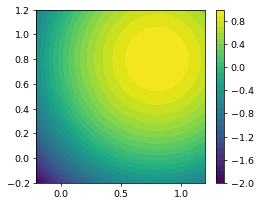

In [12]:
diff = control_max[0]-control_min[0]
xgrid0 = np.linspace(control_min[0]-0.2*diff,control_max[0]+0.2*diff,128)
diff = control_max[1]-control_min[1]
xgrid1 = np.linspace(control_min[1]-0.2*diff,control_max[1]+0.2*diff,128)
xgrid0,xgrid1 = np.meshgrid(xgrid0,xgrid1)
xgrid = np.vstack((xgrid0.flatten(), xgrid1.flatten())).T
ygrid = objective_func(xgrid,noise=0)
def plot_contour(fig,ax):
    cs = ax.tricontourf(xgrid[:,0],xgrid[:,1],ygrid,levels=32)
    fig.colorbar(cs,ax=ax)
fig,ax = plt.subplots(figsize=(4,3.3),dpi=68)
plot_contour(fig,ax)

In [13]:
obj_func = SingleTaskObjectiveFunction(
    objective_PVs = monitor_RDs,
    composite_objective_name = composite_objective_name,
    custom_function = composite_objective_func,
    objective_goal = None, 
    objective_weight = None,
    objective_tolerance = None,
)

In [14]:
evaluator = Evaluator(
    machineIO = vmio,
    control_CSETs = control_CSETs,
    control_RDs = control_RDs,
    control_tols = control_tols,
    monitor_RDs = monitor_RDs,
    df_manipulators = [obj_func.calculate_objectives_from_df],
)

In [15]:
def plot_grad(sv,epoch,evaluator=evaluator,arrow_length_factor=5):
    x = torch.tensor(np.array(sv.history['x'   ][:epoch]),dtype=torch.float64)
    y = torch.tensor(np.array(sv.history['y'   ][:epoch]),dtype=torch.float64).view(-1,1)
    ninit = len(sv.history['x'])-len(sv.history['dydx'])-1
    dxdy = np.array(sv.history['dydx'][:epoch-ninit])
    dxdy_true = get_grad(objective_func, x[ninit:]).numpy()
    print("x.shape, dxdy.shape,dxdy_true.shape",x.shape, dxdy.shape,dxdy_true.shape)

    n_grad_ave = sv.n_grad_ave
    x_min, x_max = x[-n_grad_ave:, 0].min(), x[-n_grad_ave:, 0].max()
    y_min, y_max = x[-n_grad_ave:, 1].min(), x[-n_grad_ave:, 1].max()
    x_padding = (x_max - x_min) * 1.2
    y_padding = (y_max - y_min) * 1.2
    zoom_xlim = (x_min - x_padding, x_max + x_padding)
    zoom_ylim = (y_min - y_padding, y_max + y_padding)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=150)
    current_point = x[-1]
    
    # --- Left Plot: Full Data ---
    plot_contour(fig, ax[0])
    # ax[0].set_title("Objective in latent space")
    ax[0].scatter(x[:, 0], x[:, 1], s=2, c='black', alpha=0.7, label='Training Data')
    ax[0].plot(current_point[0], current_point[1], 'rx', markersize=5, label='Current Set Point')
    
    # Add a dashed rectangle using the new dynamically calculated limits
    rect = patches.Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0],
        zoom_ylim[1] - zoom_ylim[0],
        linewidth=1.5,
        edgecolor='blue',
        alpha = 0.5,
        facecolor='none',
        linestyle='--',
        label='Zoom Area'
    )
    ax[0].add_patch(rect)
    # ax[0].set_xlim(x_min, x_max)
    # ax[0].set_ylim(y_min, y_max)
    ax[0].set_xlabel(r"$x_1$")
    ax[0].set_ylabel(r"$x_2$")
    ax[0].legend()
    ax[0].grid(True, linestyle='--', alpha=0.5)
    
    # --- Right Plot: Zoomed-in View with Gradients ---
    plot_contour(fig, ax[1])
    ax[1].scatter(x[:, 0], x[:, 1], s=4, c='black', alpha=0.7, label='trianing data')
    n = min(5,len(dxdy))
    ax[1].quiver(
        x[-n:, 0], x[-n:, 1],
        dxdy[-n:,0], dxdy[-n:,1],
        color='red',
        angles='xy',
        scale_units='xy',
        scale=1/lr,
        width=0.005,
        label='Estimated Gradients (dy/dx)'
    )
    ax[1].quiver(
        x[-n:, 0], x[-n:, 1],
        dxdy_true[-n:,0], dxdy_true[-n:,1],
        color='black',
        angles='xy',
        scale_units='xy',
        scale=1/lr,
        width=0.005,
        alpha=0.7,
        label='True Gradients (dy/dx)'
    )
    
    ax[1].plot(current_point[0], current_point[1], 'rx', markersize=4, label='currrent set point')
    ax[1].set_xlim(zoom_xlim)
    ax[1].set_ylim(zoom_ylim)
    ax[1].set_xlabel(r"$x_1$")
    ax[1].set_ylabel(r"$x_2$")
    ax[1].legend()
    ax[1].grid(True, linestyle='--', alpha=0.5)
    
    # Adjust layout and display the plot
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [16]:
def magnitude_similarity(A, B):
    """
    Compute magnitude similarity between batches of vectors.
    
    Parameters:
    A, B: numpy arrays of shape (nsamples, ndim)
    
    Returns:
    sim: numpy array of shape (nsamples,) with similarity scores
    """
    if A.shape != B.shape:
        raise ValueError("A and B must have the same shape")
    
    norms_A = np.linalg.norm(A, axis=1)
    norms_B = np.linalg.norm(B, axis=1)
    
    mins = np.minimum(norms_A, norms_B)
    maxs = np.maximum(norms_A, norms_B)
    
    # Handle case where both norms are zero (division by zero)
    sim = np.where(maxs == 0, 1.0, mins / (maxs+1e-4))
    return sim

In [17]:
def plot_hist(history,eval_hist_mean):

    fig, ax = plt.subplots(1,3,figsize=(11*1.5,3*1.5),dpi=96)
    xaxis = np.arange(len(history['y']))
    ax[0].plot(xaxis, history['y'])
    ax[0].set_xlabel('epoch');
    ax[0].set_ylabel('objective');
    ax[1].plot(xaxis, history['cpu_time'])
    ax[1].set_xlabel('epoch');
    ax[1].set_ylabel('cpu_time');
    ax[2].plot(eval_hist_mean['X0:I_RD'],eval_hist_mean['X1:I_RD'],'k',lw=1)
    xlim = ax[2].get_xlim()
    ylim = ax[2].get_ylim() 
    plot_contour(fig,ax[2])
    ax[2].scatter(eval_hist_mean['X0:I_RD'],eval_hist_mean['X1:I_RD'],s=8,c='k')
    start_x = eval_hist_mean['X0:I_RD'][0]
    start_y = eval_hist_mean['X1:I_RD'][0]
    end_x = eval_hist_mean['X0:I_RD'][-1]
    end_y = eval_hist_mean['X1:I_RD'][-1]
    ax[2].plot(start_x, start_y, 'g+', markersize=4, label='Start Point') # 'go' for green circle
    ax[2].plot(end_x, end_y, 'r*', markersize=4, label='End Point') # 'rs' for red square
    ax[2].set_xlabel('X0:I_RD')
    ax[2].set_ylabel('X1:I_RD')
    ax[2].set_title('Optimization Path')
    ax[2].legend() # Show the labels
    ax[2].set_xlim(xlim)
    ax[2].set_ylim(ylim)   
    fig.tight_layout()

    if len(history['dydx'])>0:
        x = torch.tensor(np.array(history['x']),dtype=torch.float64)
        y = torch.tensor(np.array(history['y']),dtype=torch.float64).view(-1,1)
        ninit = len(history['x'])-len(history['dydx'])
        dxdy = np.array(history['dydx'])
        cov_trace = np.array(history['cov_trace'])
        dxdy_true = get_grad(objective_func, x[ninit:]).numpy()
        cos_sim = np.sum(dxdy*dxdy_true,axis=1)/(np.linalg.norm(dxdy,axis=1)+1e-4)/(np.linalg.norm(dxdy_true,axis=1)+1e-4)
        mag_sim = magnitude_similarity(dxdy,dxdy_true)
        history['dydx_true'] = dxdy_true
        history['cos_sim'] = cos_sim
        history['mag_sim'] = mag_sim
        fig, ax = plt.subplots(1,2,figsize=(15,4),dpi=96)
        ax[0].plot(np.arange(len(cos_sim))+ninit,cos_sim,'o-',label='cosine similarity')
        ax[0].plot(np.arange(len(mag_sim))+ninit,mag_sim,'o-',label='magnitude similarity')
        ax[0].set_xlabel('epoch')
        ax[0].set_ylabel('similarity')
        ax[0].set_ylim(-1.1,1.1)
        ax[0].legend()
        ax[1].plot(np.arange(len(cov_trace))+ninit,cov_trace,'o-',label='trace of gradient covariance')
        if len(history['probability'])>0:
            ax[1].plot(np.arange(len(history['probability']))+ninit,history['probability'],'o-',label='probability of ascent')
        ax[1].legend()
        ax[1].set_xlabel('epoch')
        fig.tight_layout()




# NM

In [18]:
import numpy as np
from scipy.optimize import minimize

def optimize_with_nelder_mead(savo,  max_evals=budget): #delta=0.1*max_dx*ndim**0.5,
    x0 = savo.x
    n = len(x0)
    delta=max_dx*ndim**0.5

    # Create initial simplex: first vertex is x0,
    # others are x0 + delta along each dimension
    initial_simplex = [x0]
    for i in range(n):
        vertex = np.array(x0, copy=True)
        vertex[i] += delta
        initial_simplex.append(vertex)
    initial_simplex = np.array(initial_simplex)

    def loss_fn(x):
        return savo.evaluate(x)

    result = minimize(
        loss_fn,
        x0,
        method='Nelder-Mead',
        options={
            'initial_simplex': initial_simplex,
            'maxfev': max_evals,
        }
    )
    return result

In [19]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator)
result = optimize_with_nelder_mead(sv,max_evals=budget)

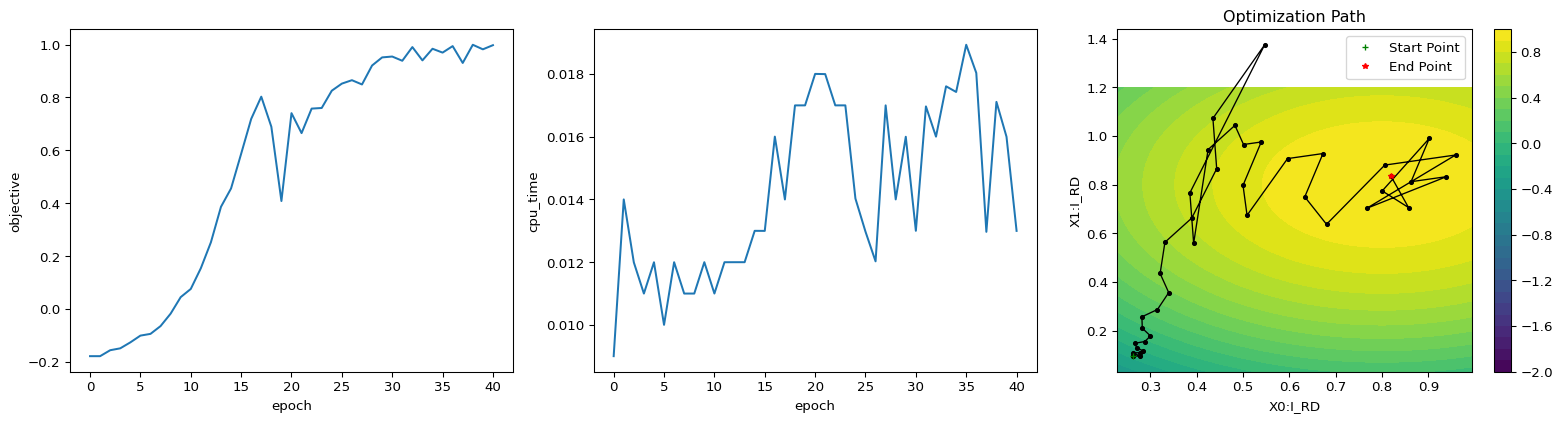

In [20]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [21]:
svNM = copy(sv.history)
evNM = copy(sv.evaluator.get_history()['mean'])

# ES

In [22]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, lrES=lrES)
for i in range(budget):
    sv.step(lr=0)

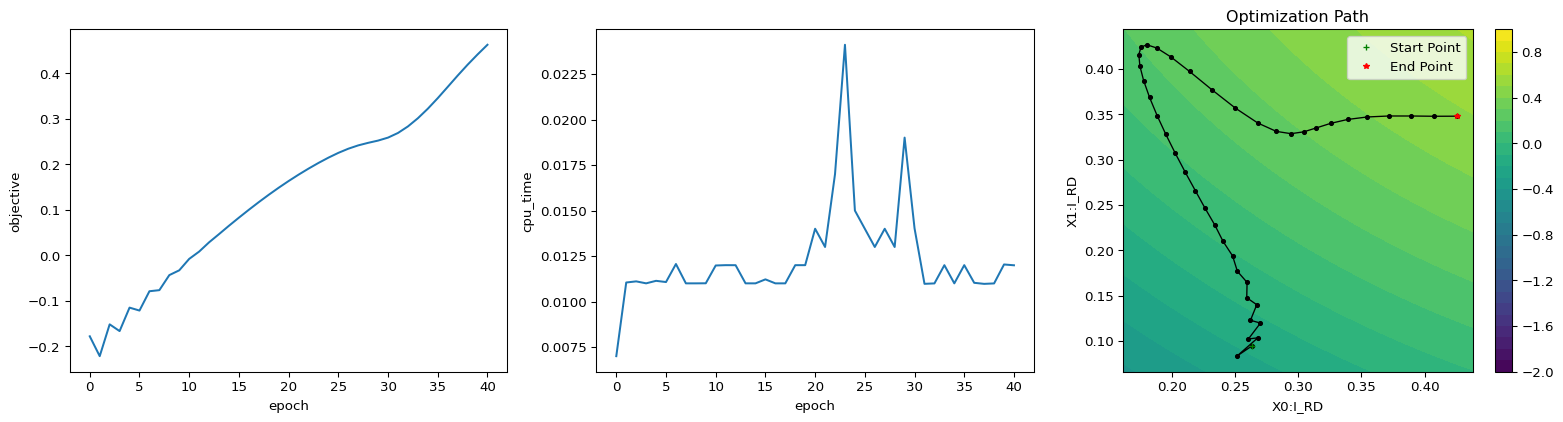

In [23]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [24]:
svES = copy(sv.history)
evES = copy(sv.evaluator.get_history()['mean'])

# NM vs ES plot

(0.0, 40.0)

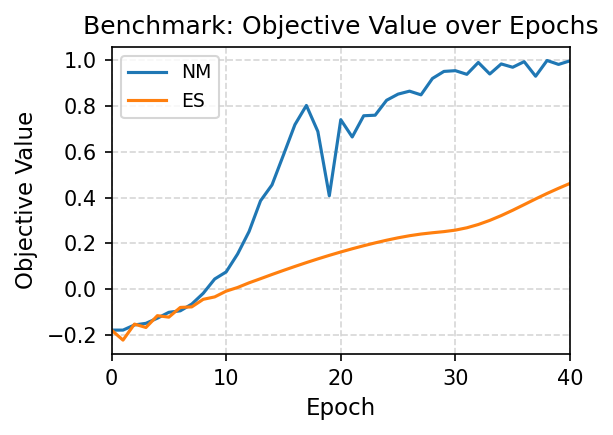

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'NM': svNM,
    'ES': svES,
}

# Plot settings
plt.figure(figsize=(4, 3), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim(0,budget)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
# plt.savefig(f'{fname}_NMvsES.png',dpi=150)

# ES + adamSG

In [26]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
optimizer = adam()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, lrES=lrES, optimizer=optimizer)
for i in range(ninit):
    sv.step(lr=0)
for i in range(budget-ninit):
    sv.step(lr=lr)

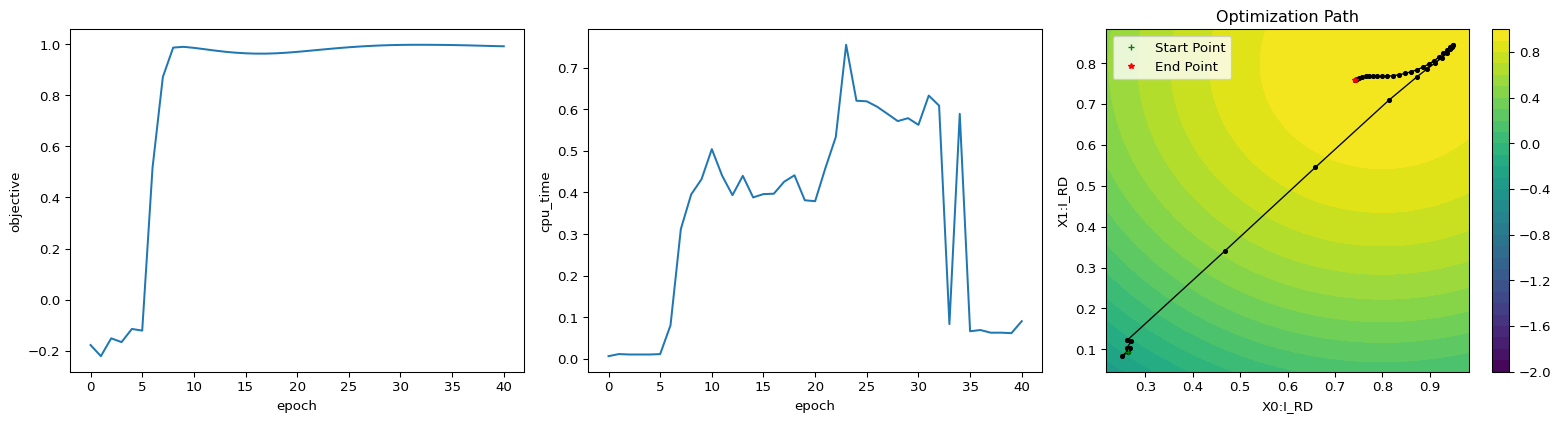

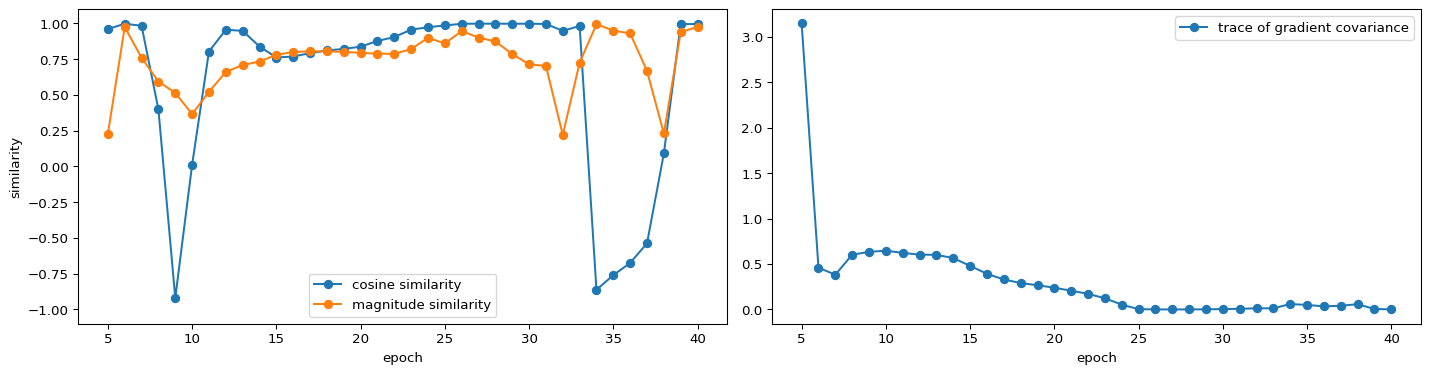

In [27]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

x.shape, dxdy.shape,dxdy_true.shape torch.Size([9, 2]) (5, 2) (5, 2)


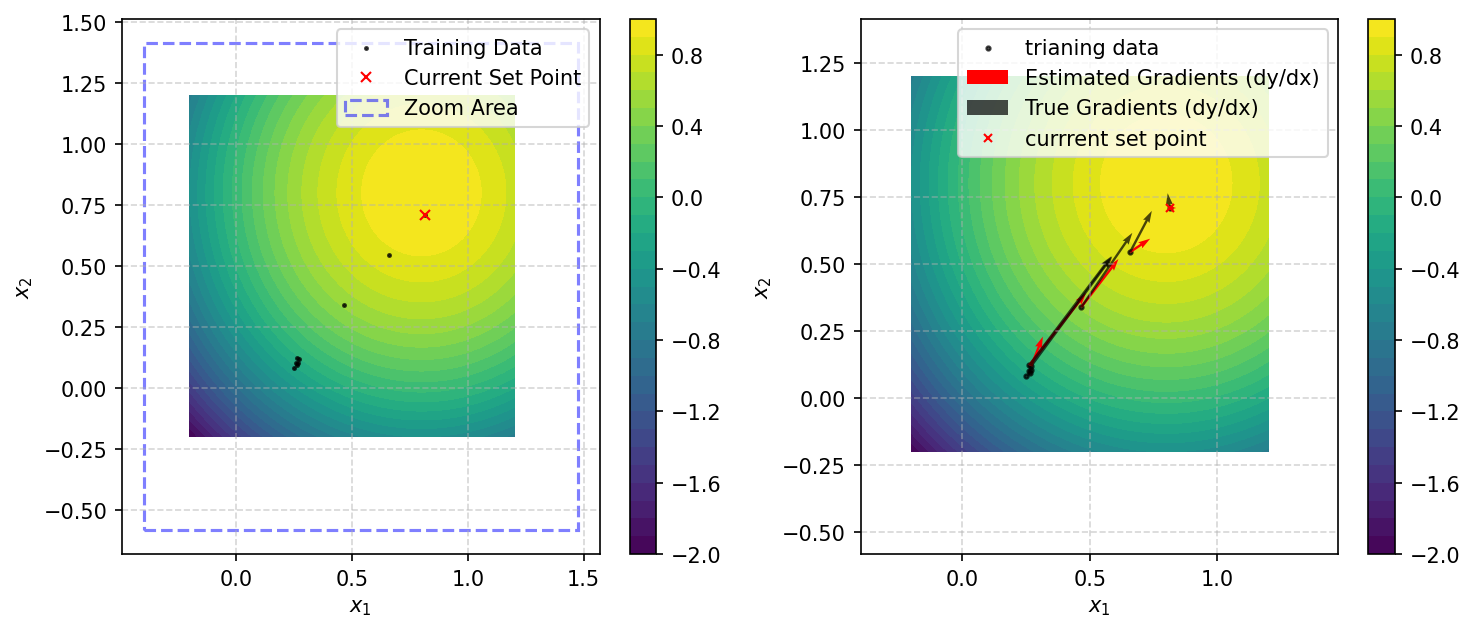

x.shape, dxdy.shape,dxdy_true.shape torch.Size([14, 2]) (10, 2) (10, 2)


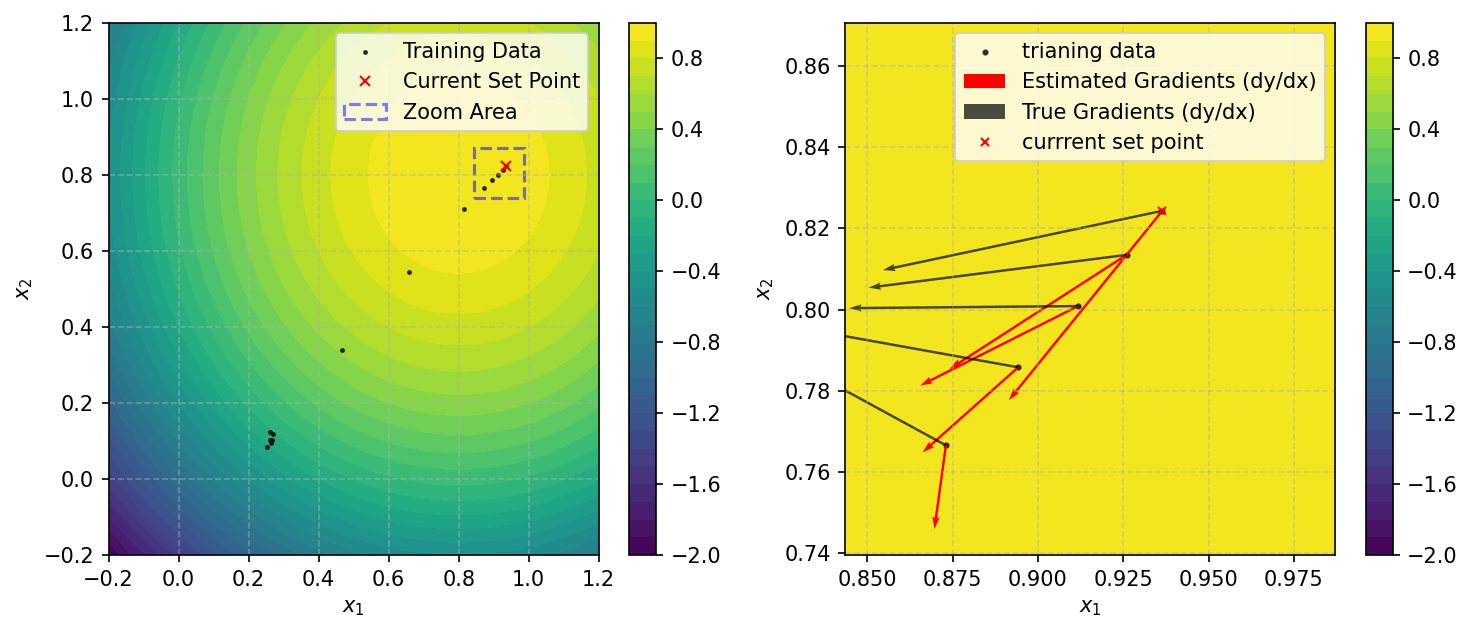

x.shape, dxdy.shape,dxdy_true.shape torch.Size([25, 2]) (21, 2) (21, 2)


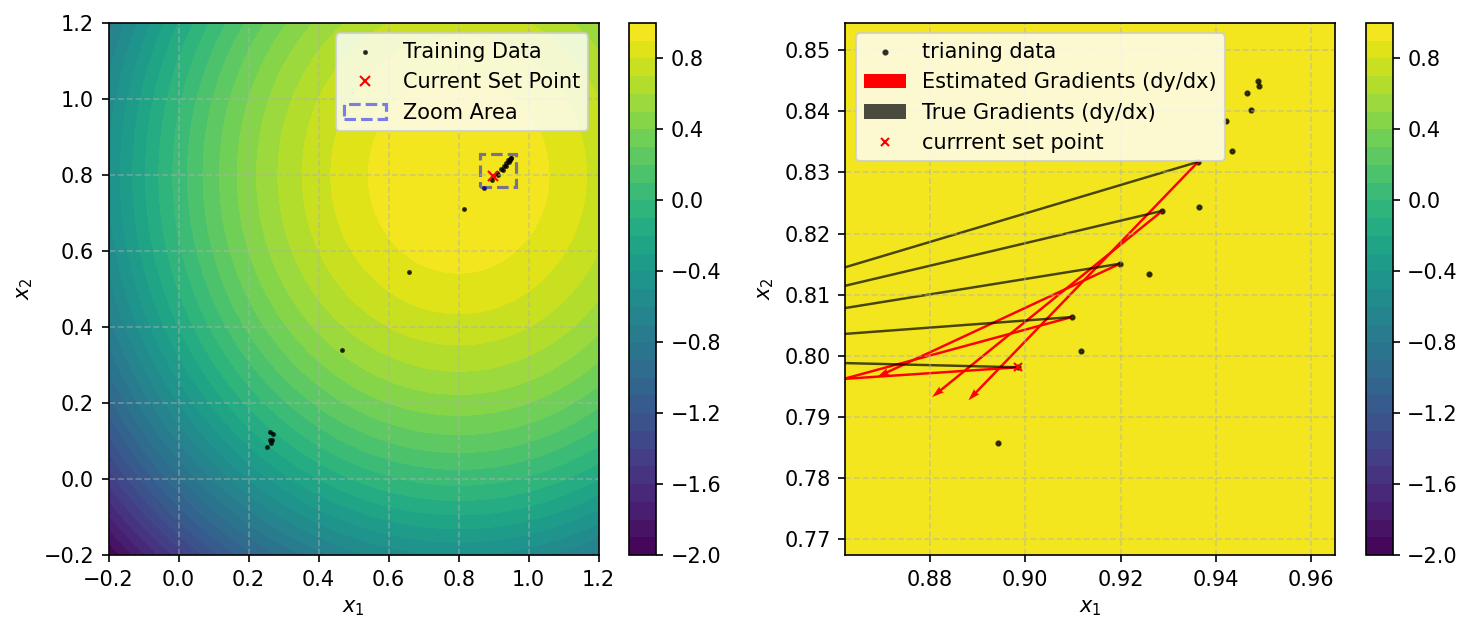

x.shape, dxdy.shape,dxdy_true.shape torch.Size([40, 2]) (36, 2) (36, 2)


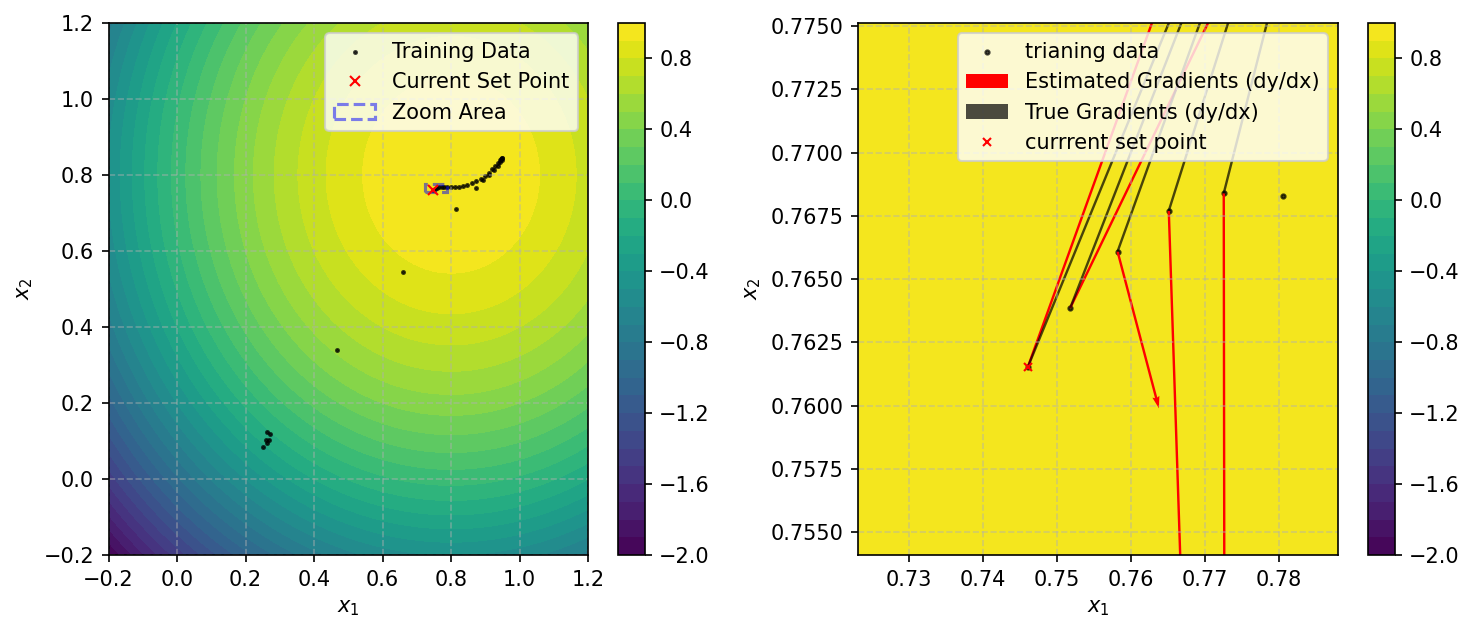

In [28]:
plot_grad(sv,epoch=ninit+5)
plot_grad(sv,epoch=int(0.3*(budget-ninit))+ninit)
plot_grad(sv,epoch=int(0.6*(budget-ninit))+ninit)
plot_grad(sv,epoch=budget)

In [29]:
svAdamSGES = copy(sv.history)
evAdamSGES = copy(sv.evaluator.get_history()['mean'])

# ES + SG

In [30]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, lrES=lrES)
for i in range(ninit):
    sv.step(lr=0)
for i in range(budget-ninit):
    sv.step(lr=lr)

c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative var

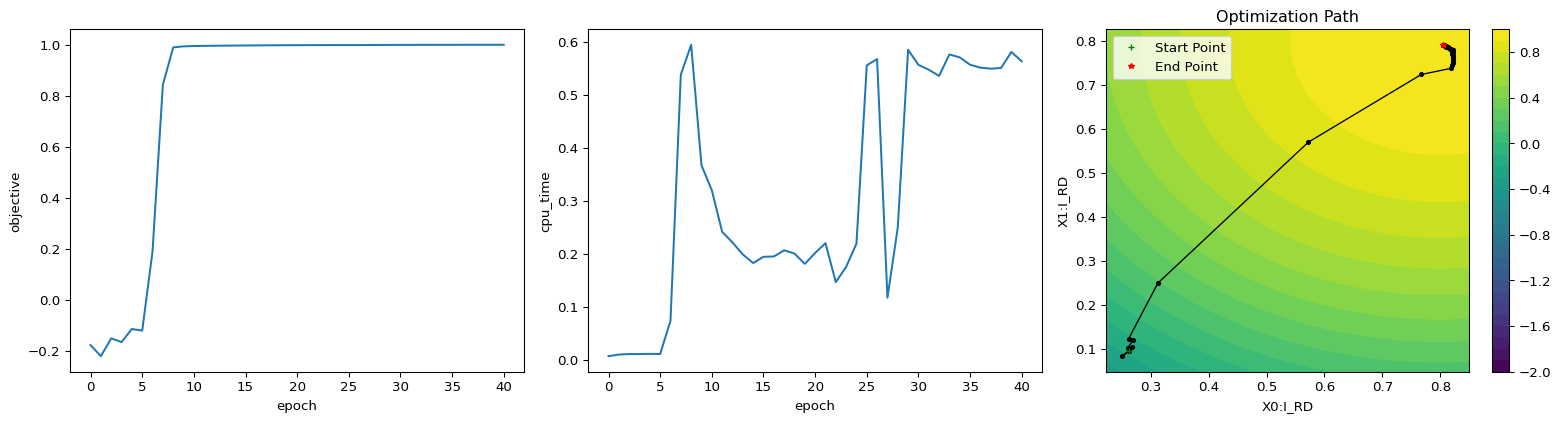

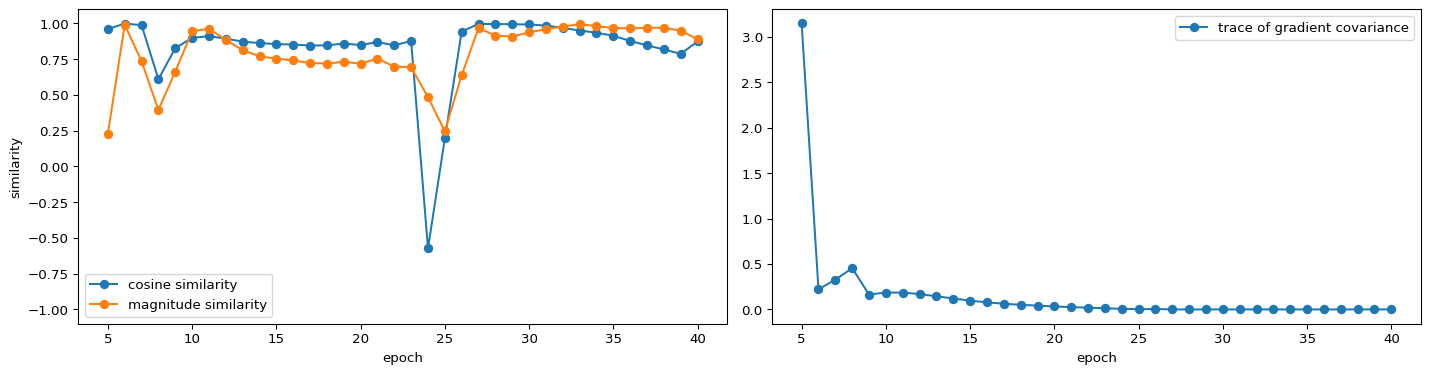

In [31]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

x.shape, dxdy.shape,dxdy_true.shape torch.Size([9, 2]) (5, 2) (5, 2)


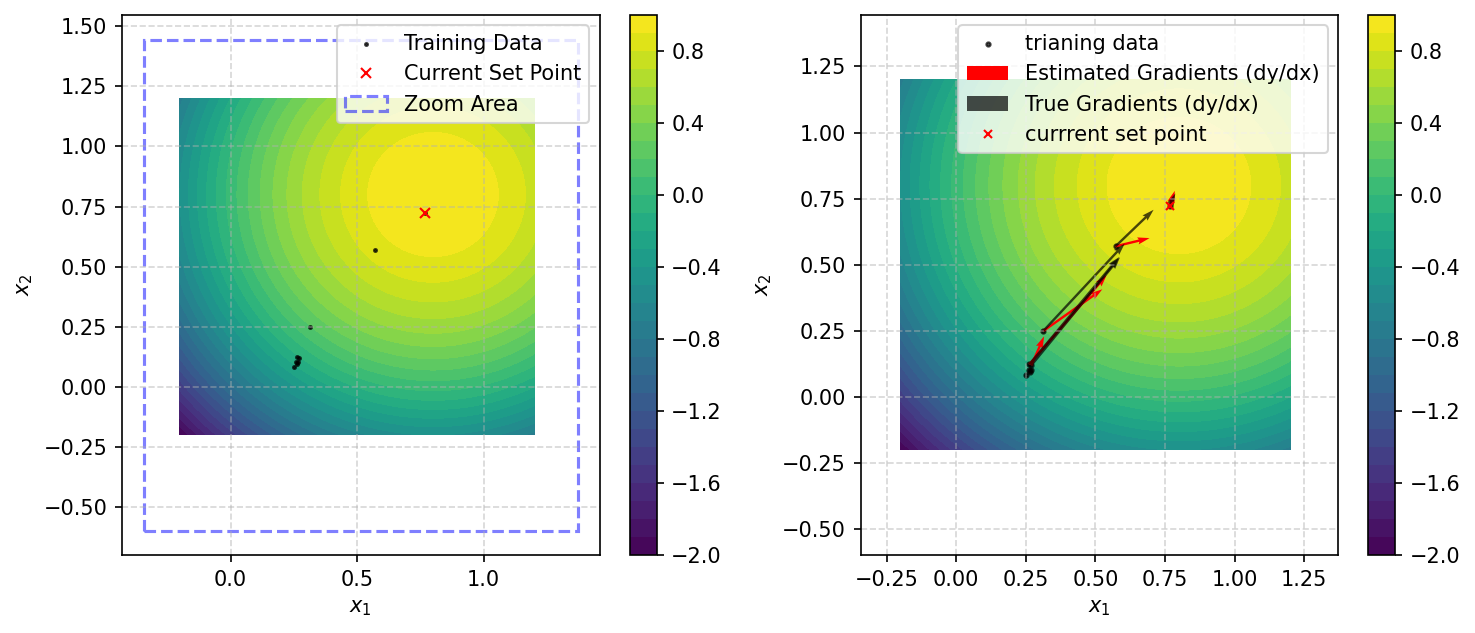

x.shape, dxdy.shape,dxdy_true.shape torch.Size([14, 2]) (10, 2) (10, 2)


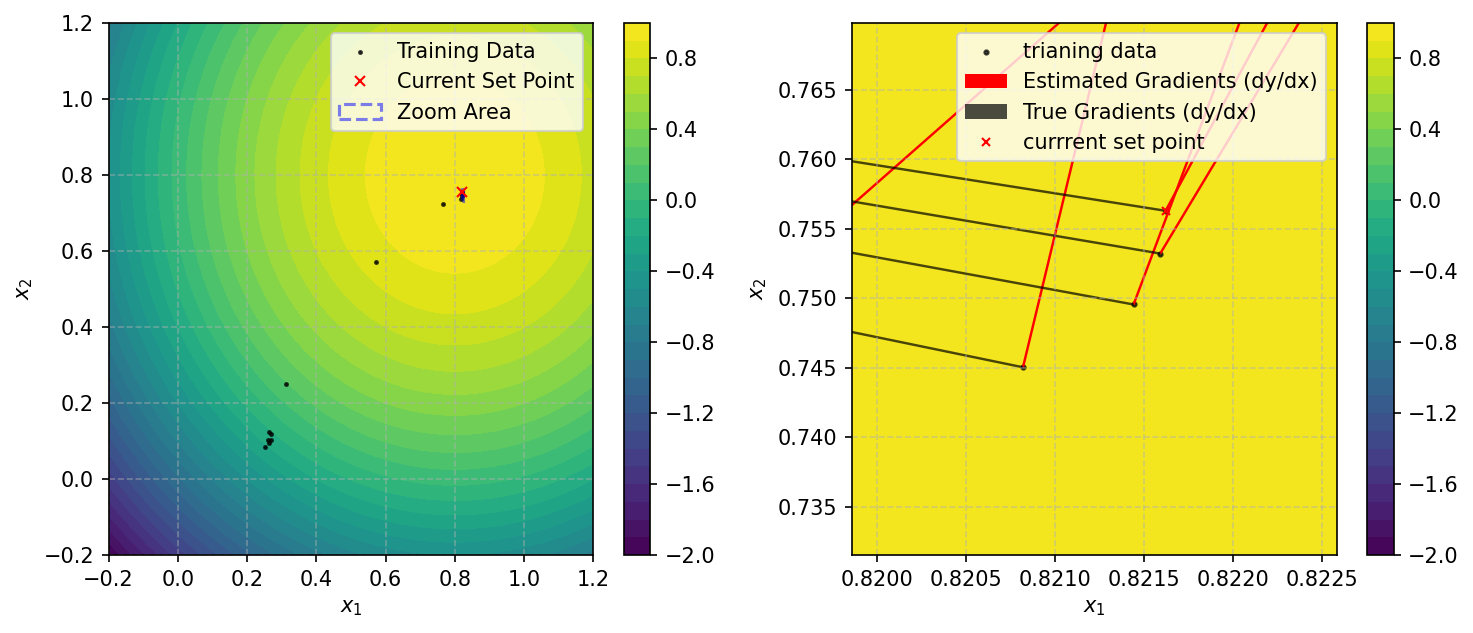

x.shape, dxdy.shape,dxdy_true.shape torch.Size([25, 2]) (21, 2) (21, 2)


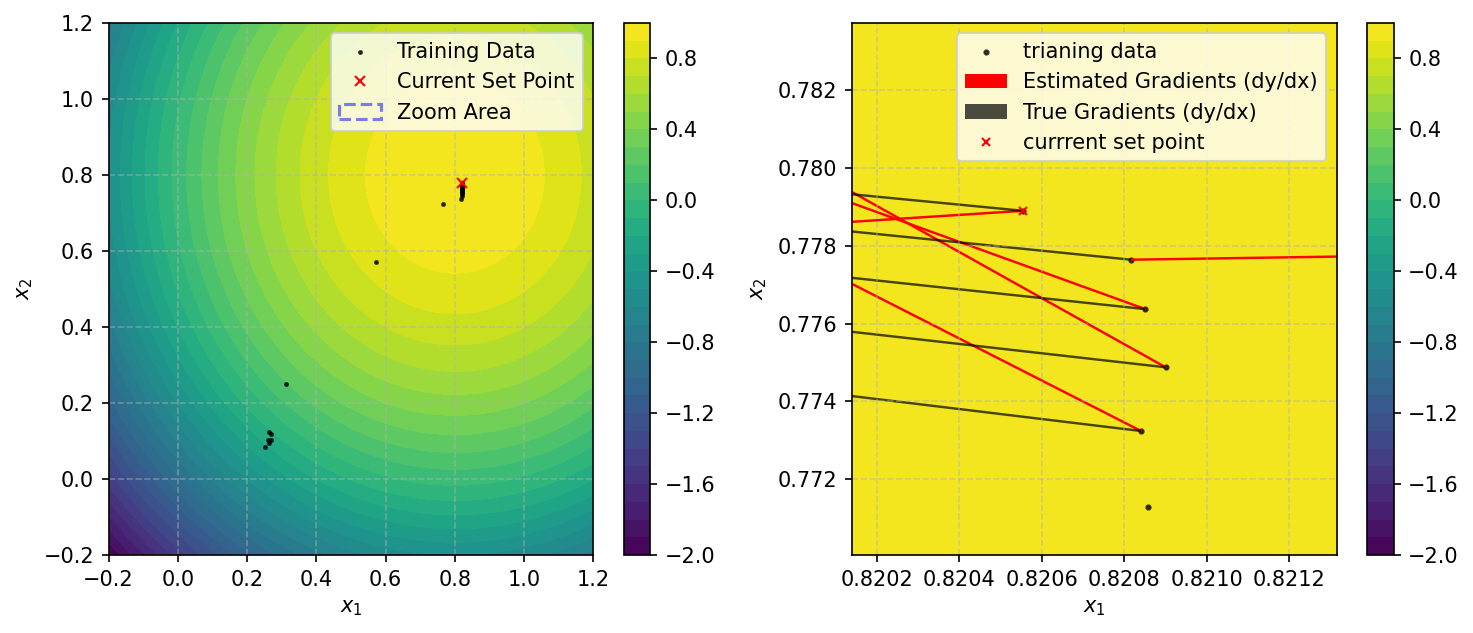

x.shape, dxdy.shape,dxdy_true.shape torch.Size([40, 2]) (36, 2) (36, 2)


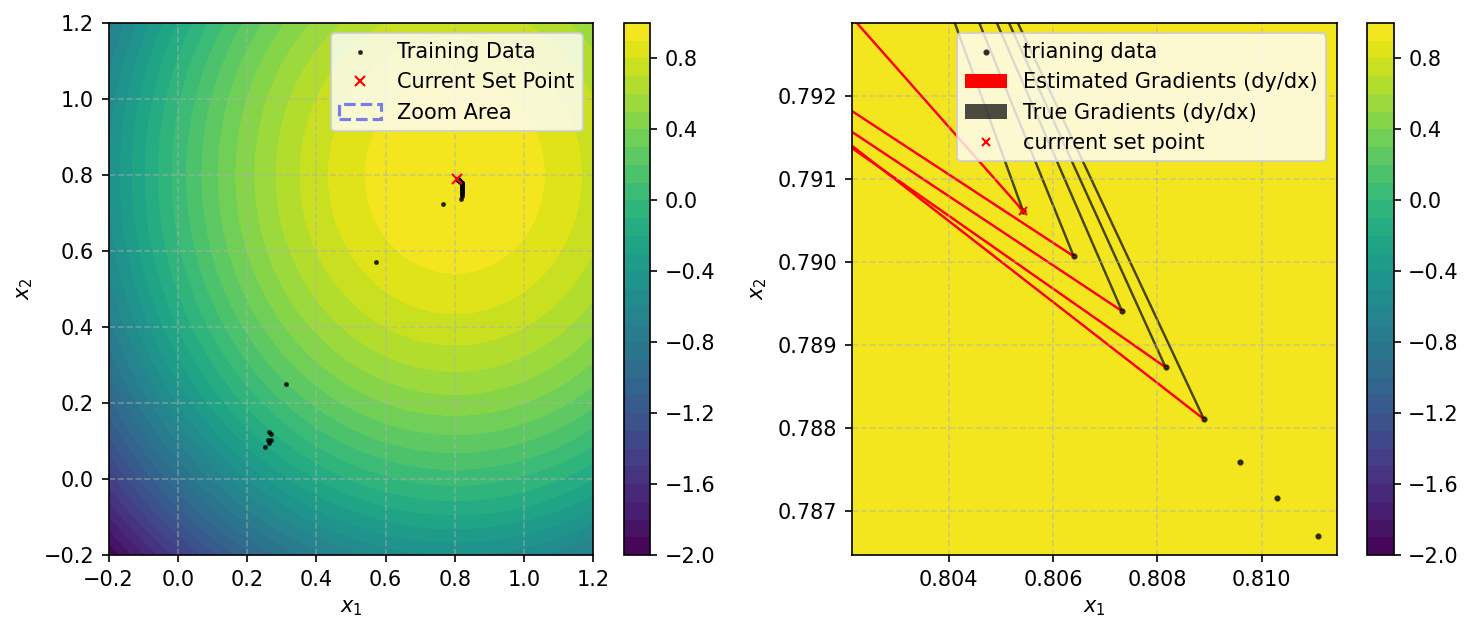

In [32]:
plot_grad(sv,epoch=ninit+5)
plot_grad(sv,epoch=int(0.3*(budget-ninit))+ninit)
plot_grad(sv,epoch=int(0.6*(budget-ninit))+ninit)
plot_grad(sv,epoch=budget)

In [33]:
svSGES = copy(sv.history)
evSGES = copy(sv.evaluator.get_history()['mean'])

# ES + SG penalize_uncertain_gradient

In [34]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, lrES=lrES)
for i in range(ninit):
    sv.step(lr=0)
for i in range(budget-ninit):
    sv.step(lr=lr,penalize_uncertain_gradient=True)

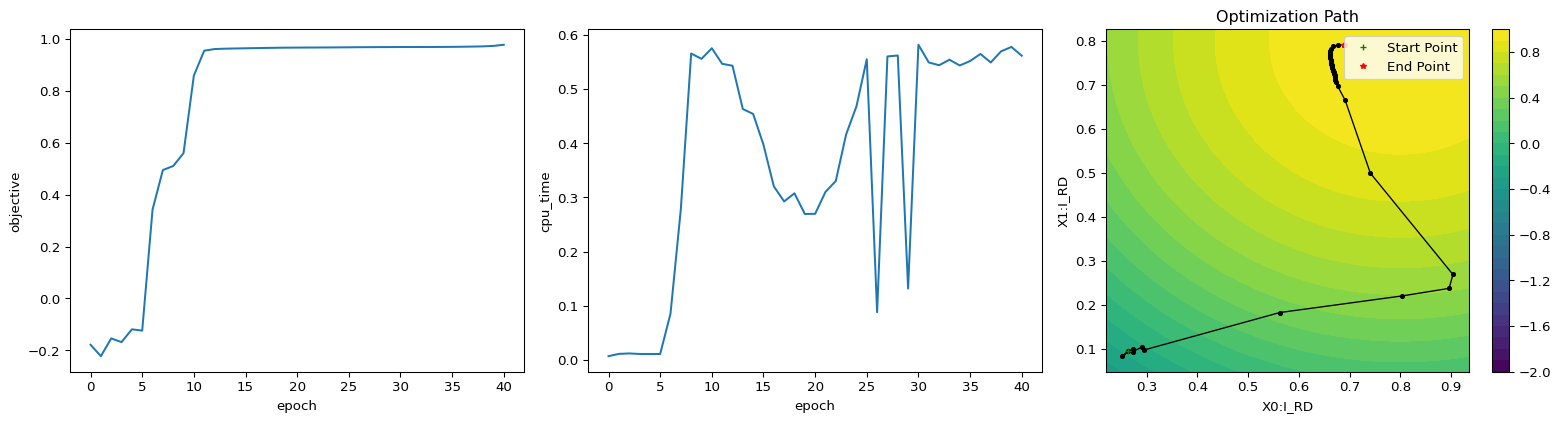

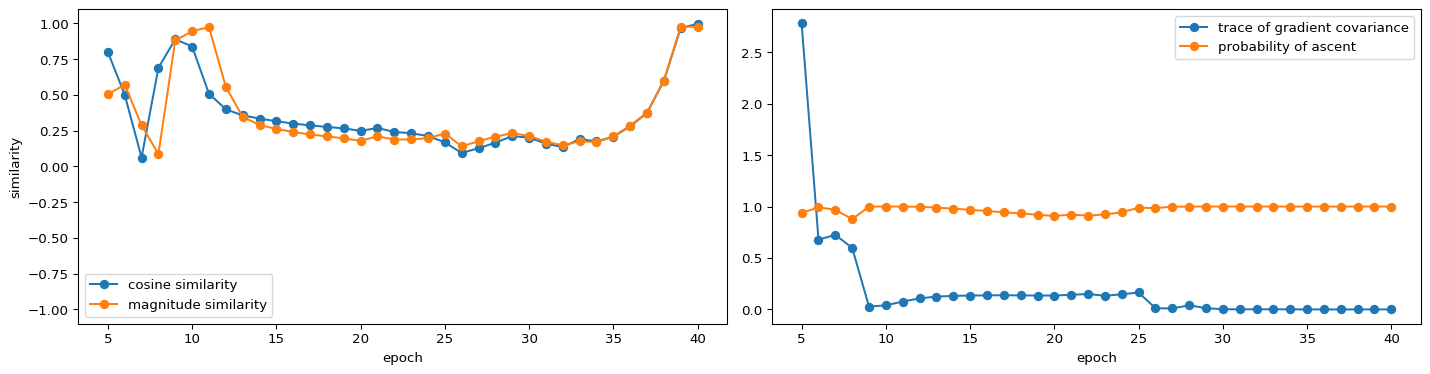

In [35]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

x.shape, dxdy.shape,dxdy_true.shape torch.Size([9, 2]) (5, 2) (5, 2)


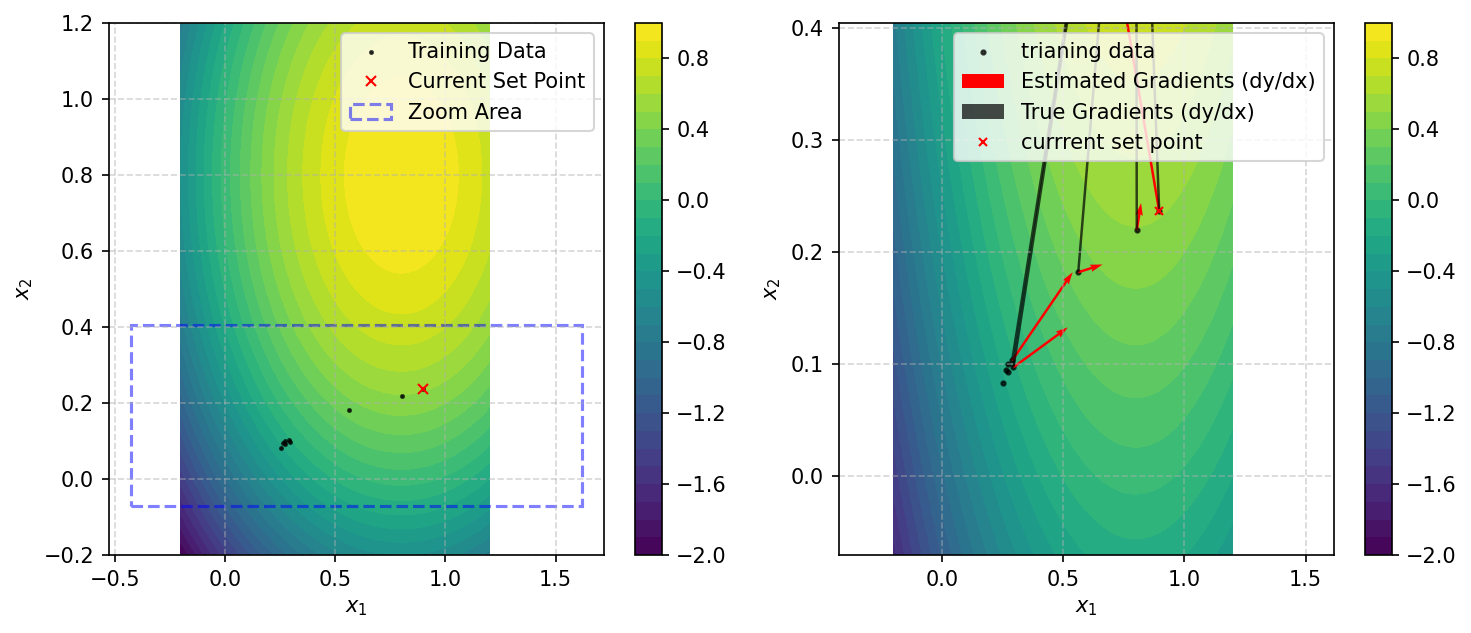

x.shape, dxdy.shape,dxdy_true.shape torch.Size([14, 2]) (10, 2) (10, 2)


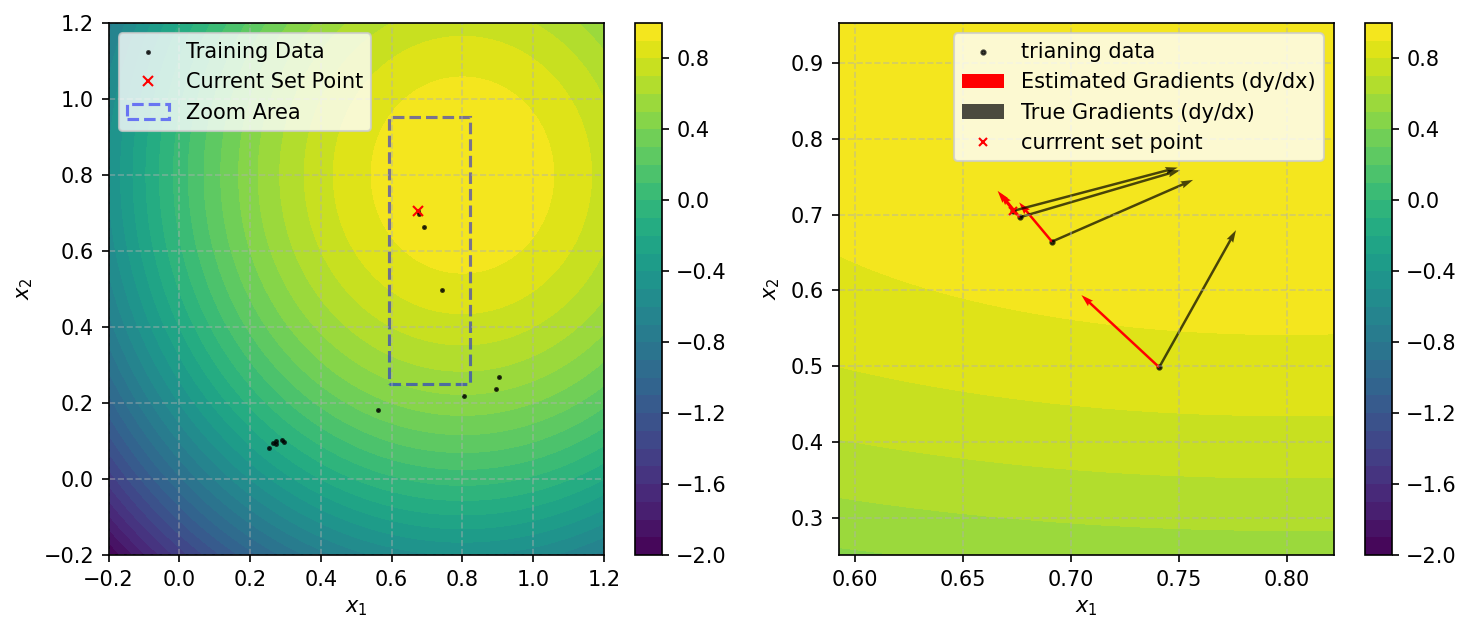

x.shape, dxdy.shape,dxdy_true.shape torch.Size([25, 2]) (21, 2) (21, 2)


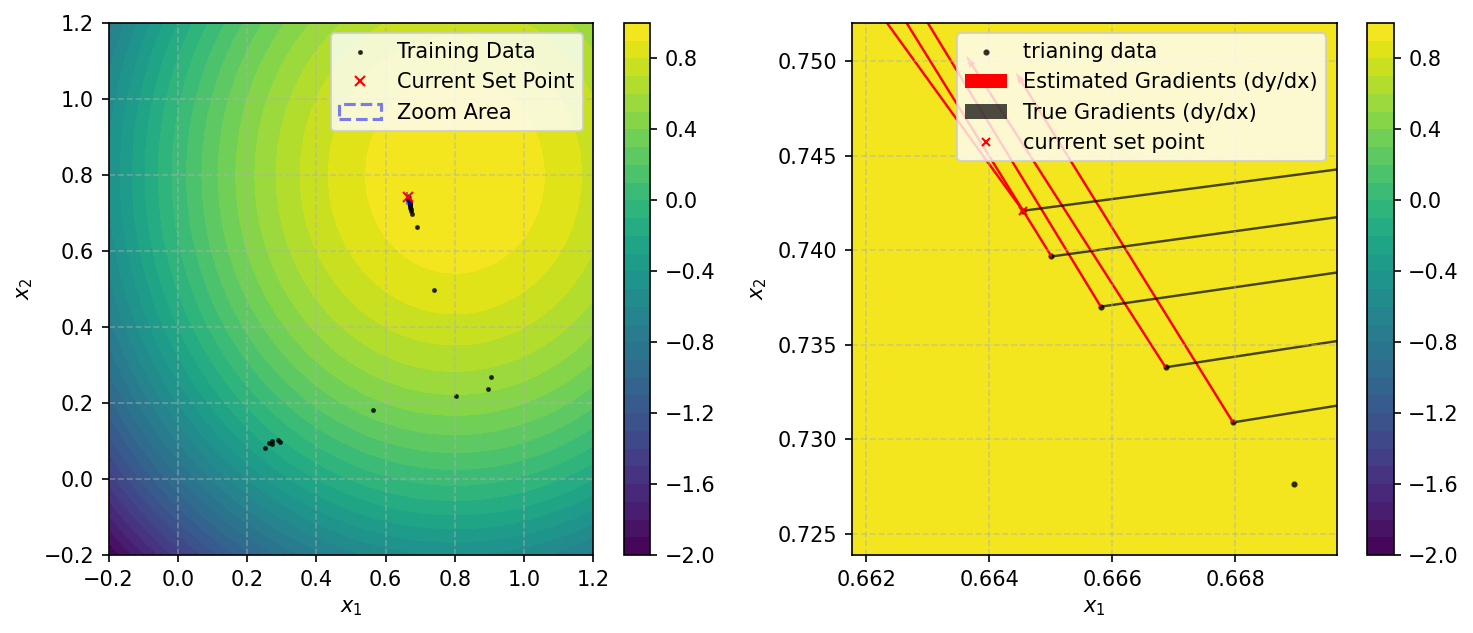

x.shape, dxdy.shape,dxdy_true.shape torch.Size([40, 2]) (36, 2) (36, 2)


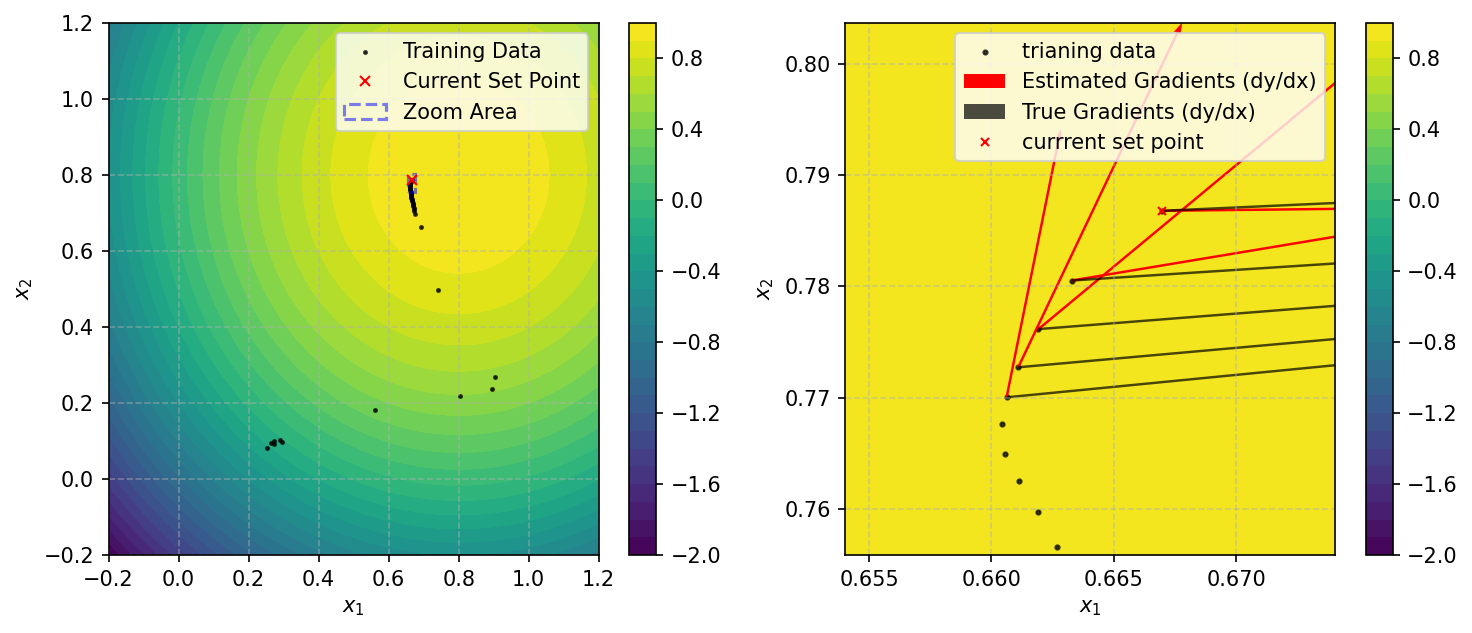

In [36]:
plot_grad(sv,epoch=ninit+5)
plot_grad(sv,epoch=int(0.3*(budget-ninit))+ninit)
plot_grad(sv,epoch=int(0.6*(budget-ninit))+ninit)
plot_grad(sv,epoch=budget)

In [37]:
svSGESuncertain = copy(sv.history)
evSGESuncertain = copy(sv.evaluator.get_history()['mean'])

# ES + adamSG penalize_uncertain_gradient

In [38]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, lrES=lrES, optimizer = adam())
for i in range(ninit):
    sv.step(lr=0)
for i in range(budget-ninit):
    sv.step(lr=lr,penalize_uncertain_gradient=True)

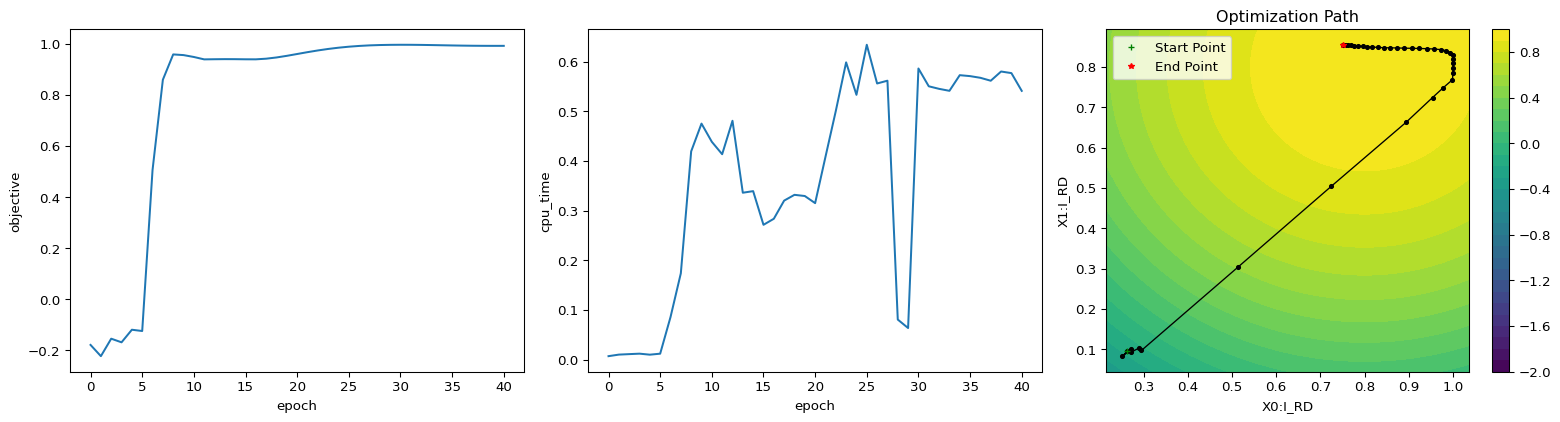

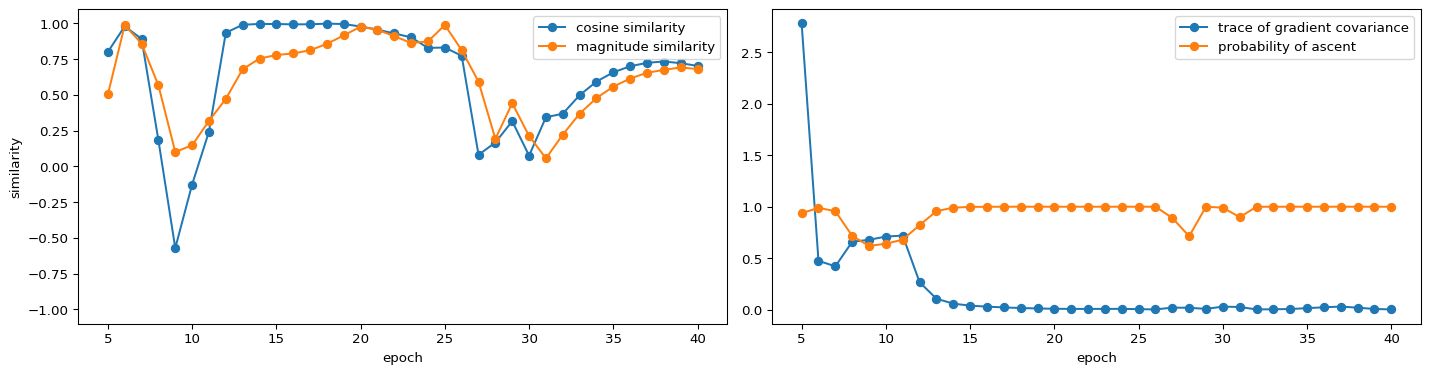

In [39]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

x.shape, dxdy.shape,dxdy_true.shape torch.Size([14, 2]) (10, 2) (10, 2)


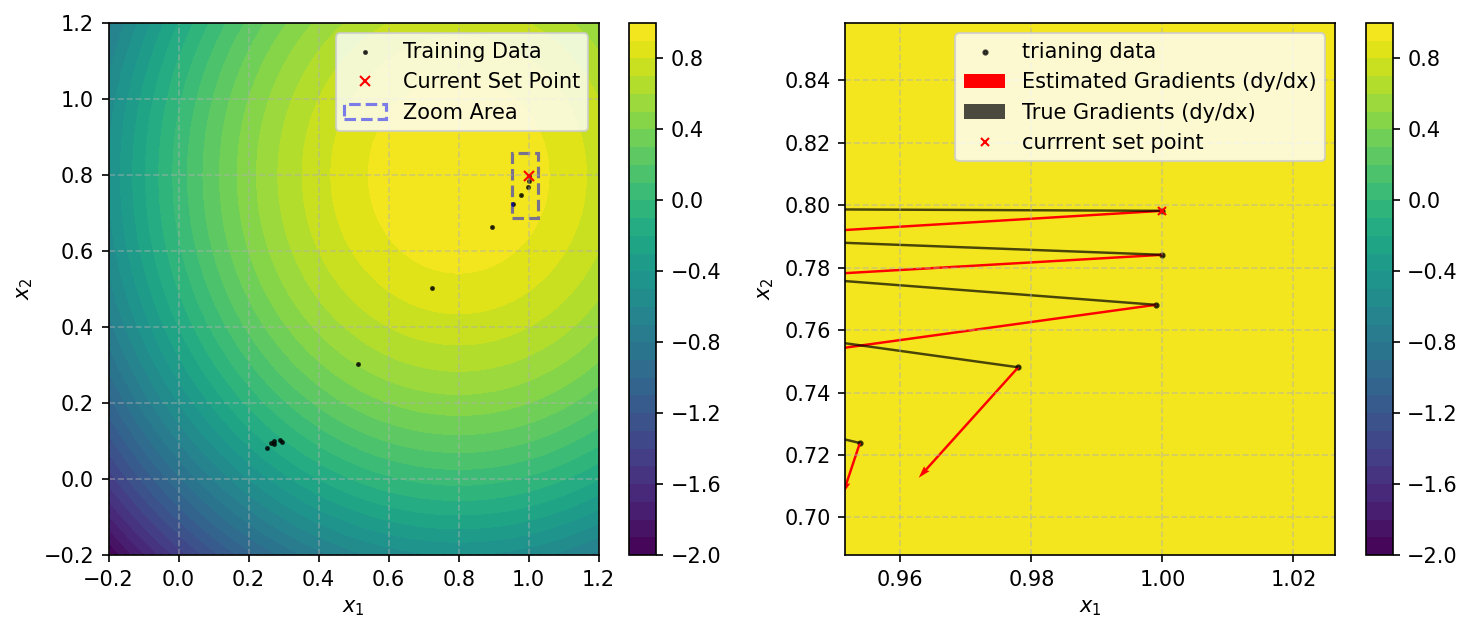

x.shape, dxdy.shape,dxdy_true.shape torch.Size([12, 2]) (8, 2) (8, 2)


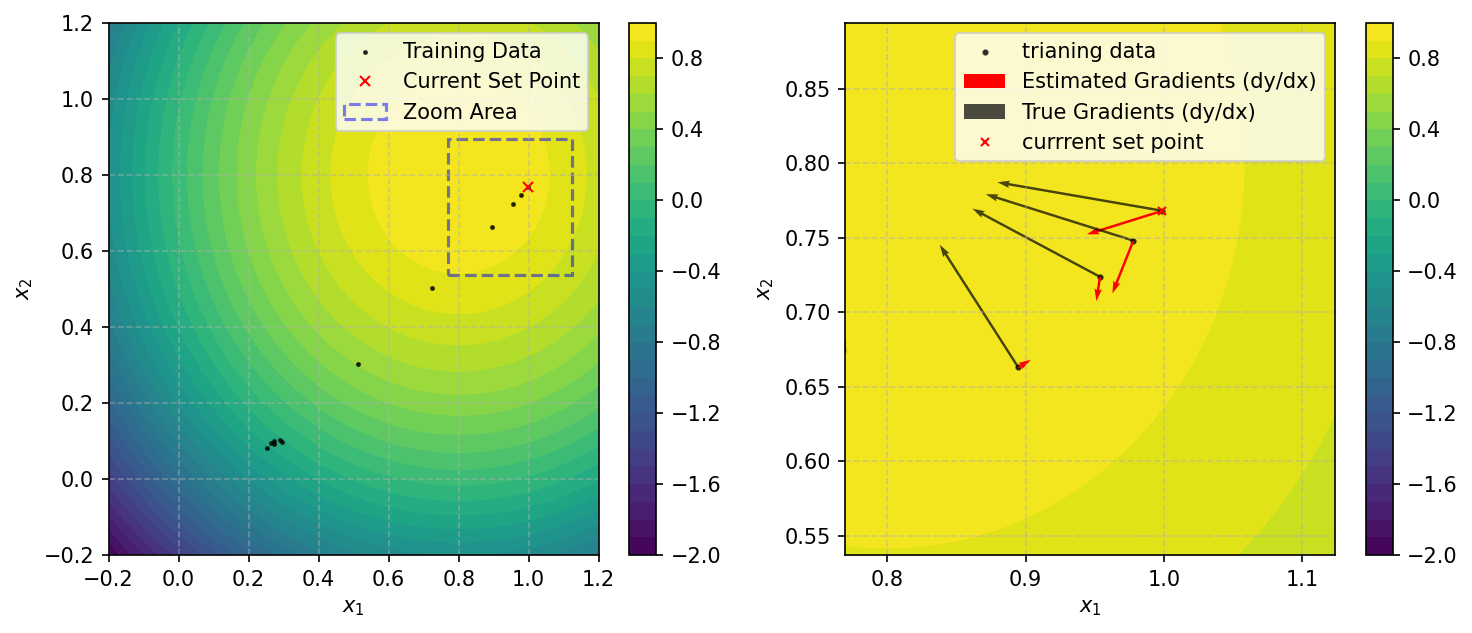

x.shape, dxdy.shape,dxdy_true.shape torch.Size([24, 2]) (20, 2) (20, 2)


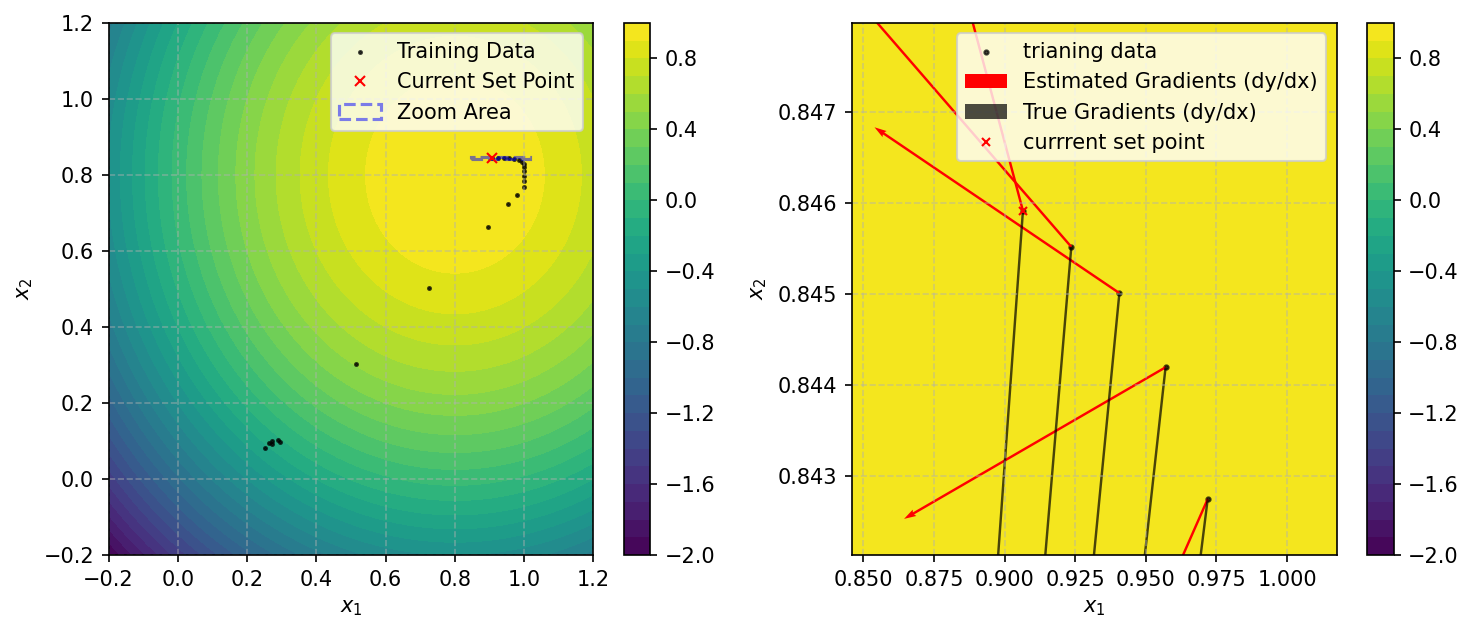

x.shape, dxdy.shape,dxdy_true.shape torch.Size([40, 2]) (36, 2) (36, 2)


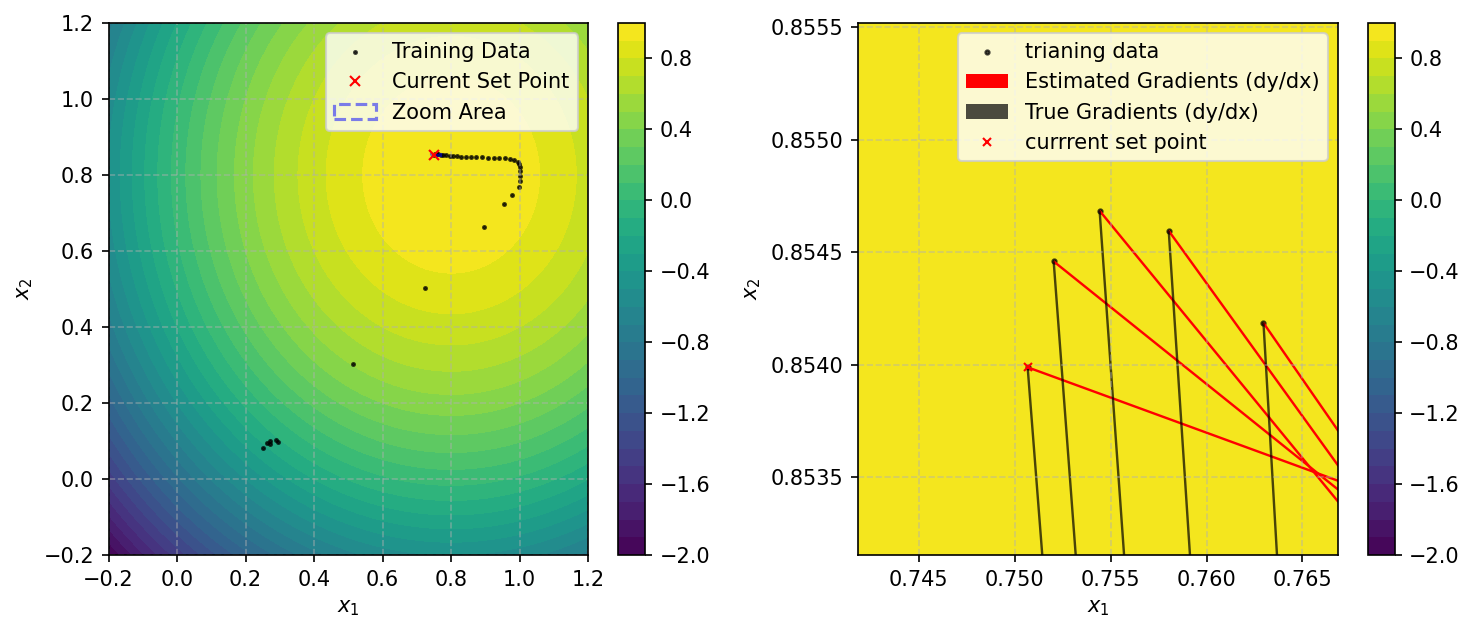

In [40]:
plot_grad(sv,epoch=ninit+10)
plot_grad(sv,epoch=int(0.3*budget))
plot_grad(sv,epoch=int(0.6*budget))
plot_grad(sv,epoch=budget)

In [41]:
svAdamSGESuncertain = copy(sv.history)
evAdamSGESuncertain = copy(sv.evaluator.get_history()['mean'])

# SG wo ES

In [42]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, lrES=lrES)
for i in range(ninit):
    sv.step(lr=0)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES_scaler=0.0)

c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative var

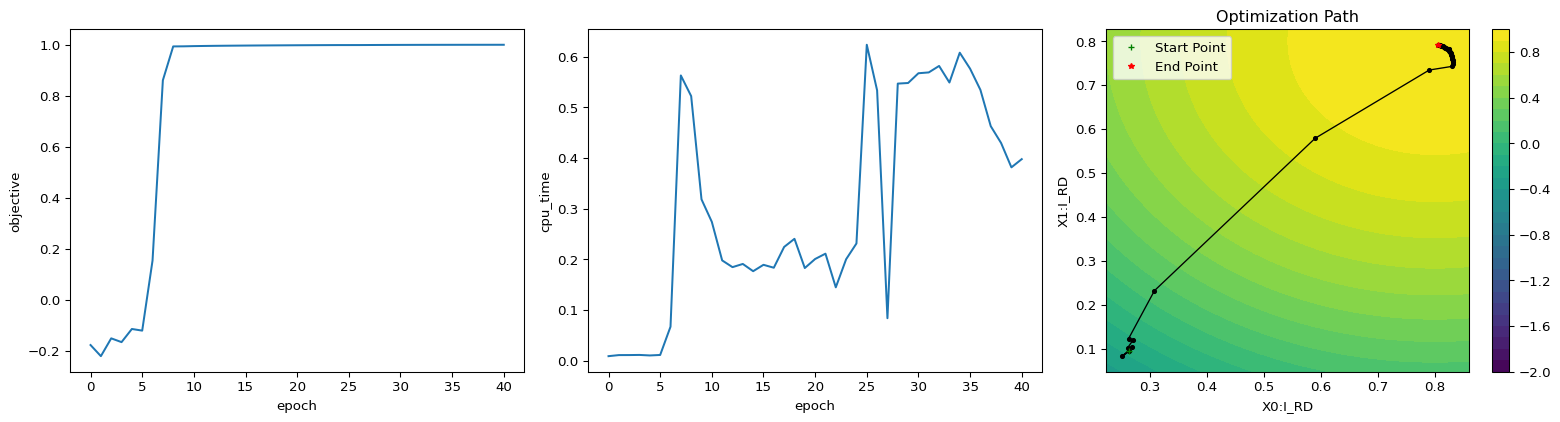

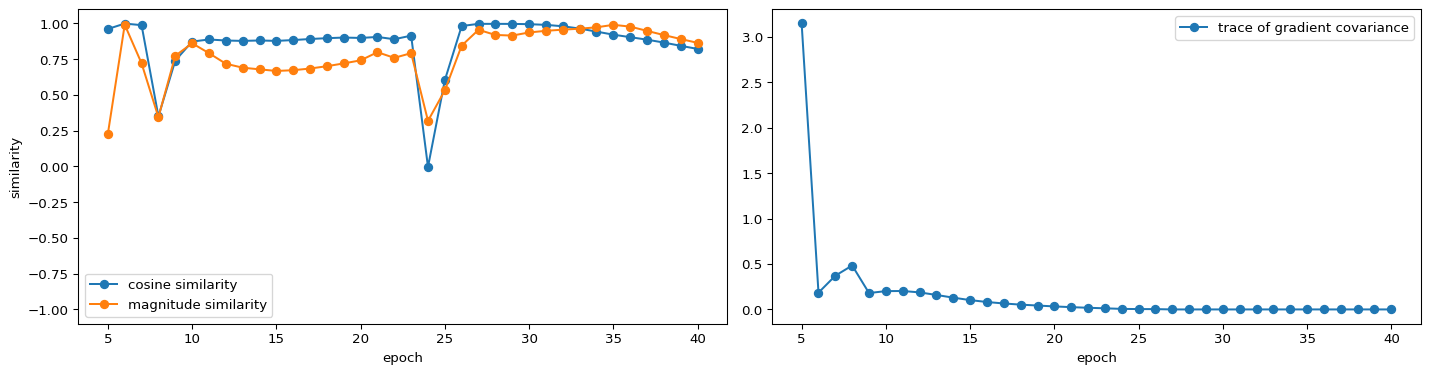

In [43]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

x.shape, dxdy.shape,dxdy_true.shape torch.Size([9, 2]) (5, 2) (5, 2)


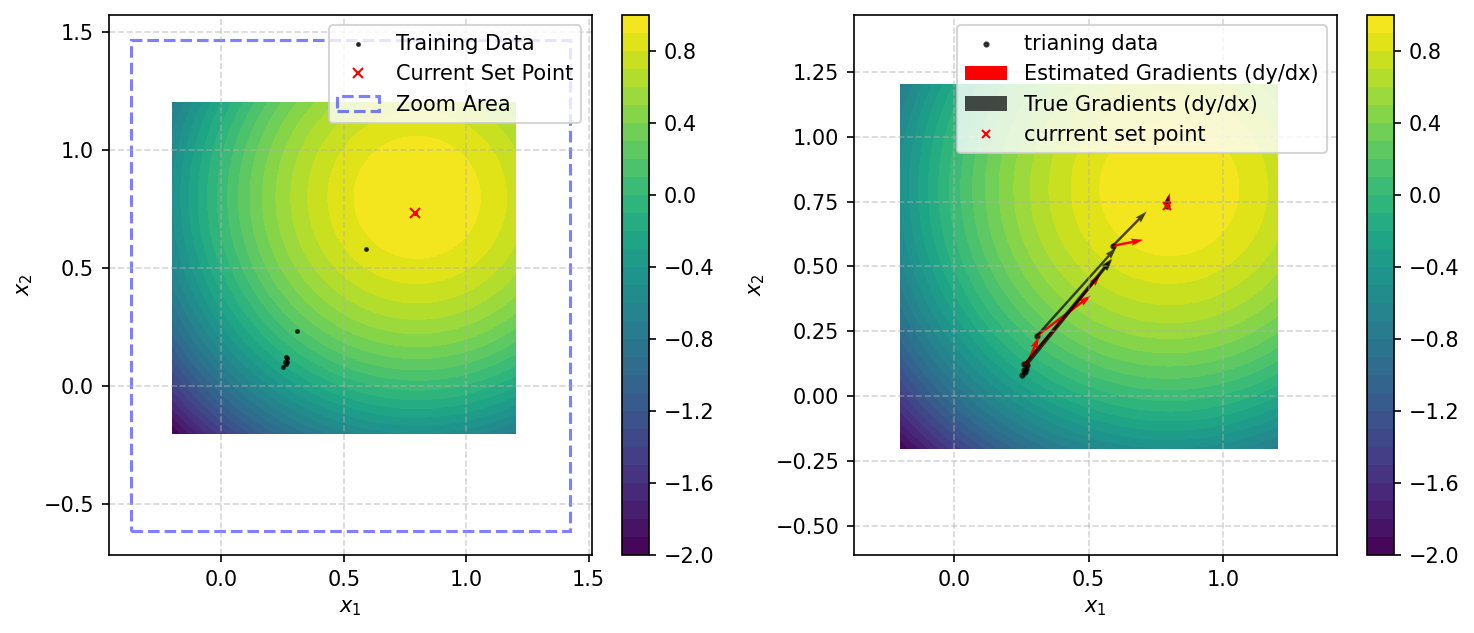

x.shape, dxdy.shape,dxdy_true.shape torch.Size([14, 2]) (10, 2) (10, 2)


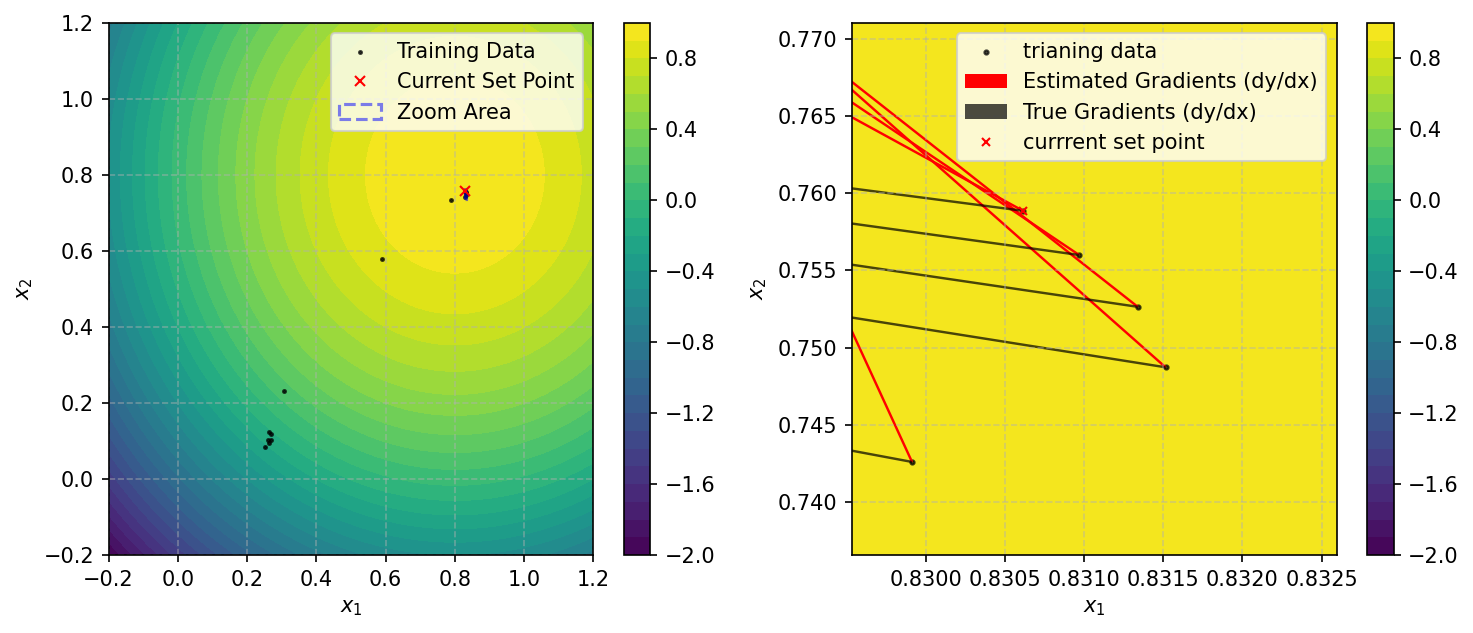

x.shape, dxdy.shape,dxdy_true.shape torch.Size([25, 2]) (21, 2) (21, 2)


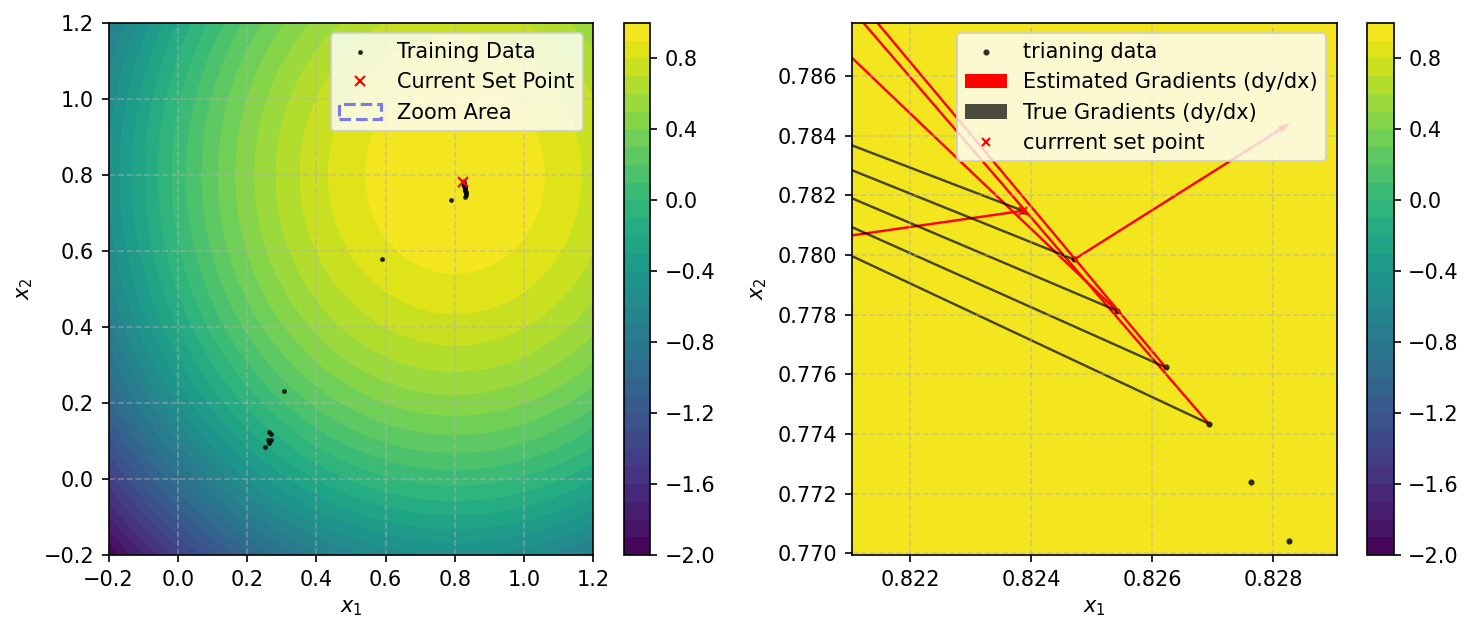

x.shape, dxdy.shape,dxdy_true.shape torch.Size([40, 2]) (36, 2) (36, 2)


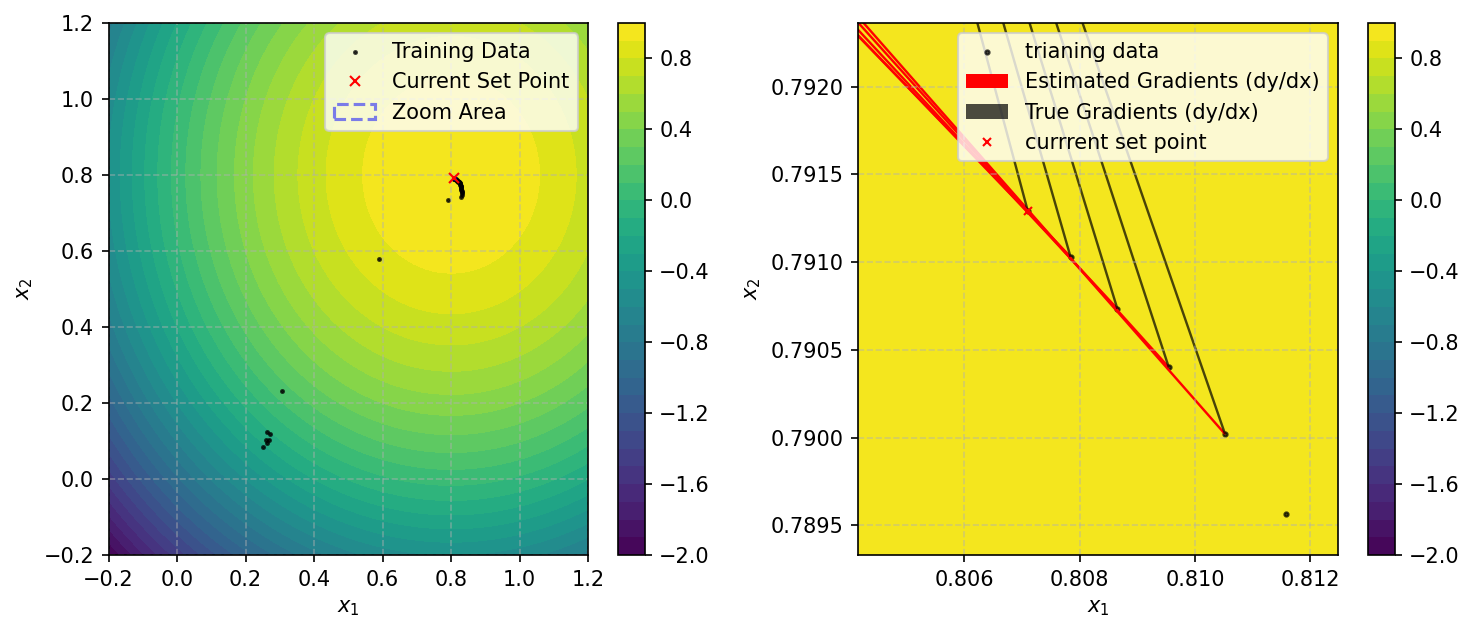

In [44]:
plot_grad(sv,epoch=ninit+5)
plot_grad(sv,epoch=int(0.3*(budget-ninit))+ninit)
plot_grad(sv,epoch=int(0.6*(budget-ninit))+ninit)
plot_grad(sv,epoch=budget)

In [45]:
svSG = copy(sv.history)
evSG = copy(sv.evaluator.get_history()['mean'])

x.shape, dxdy.shape,dxdy_true.shape torch.Size([9, 2]) (5, 2) (5, 2)


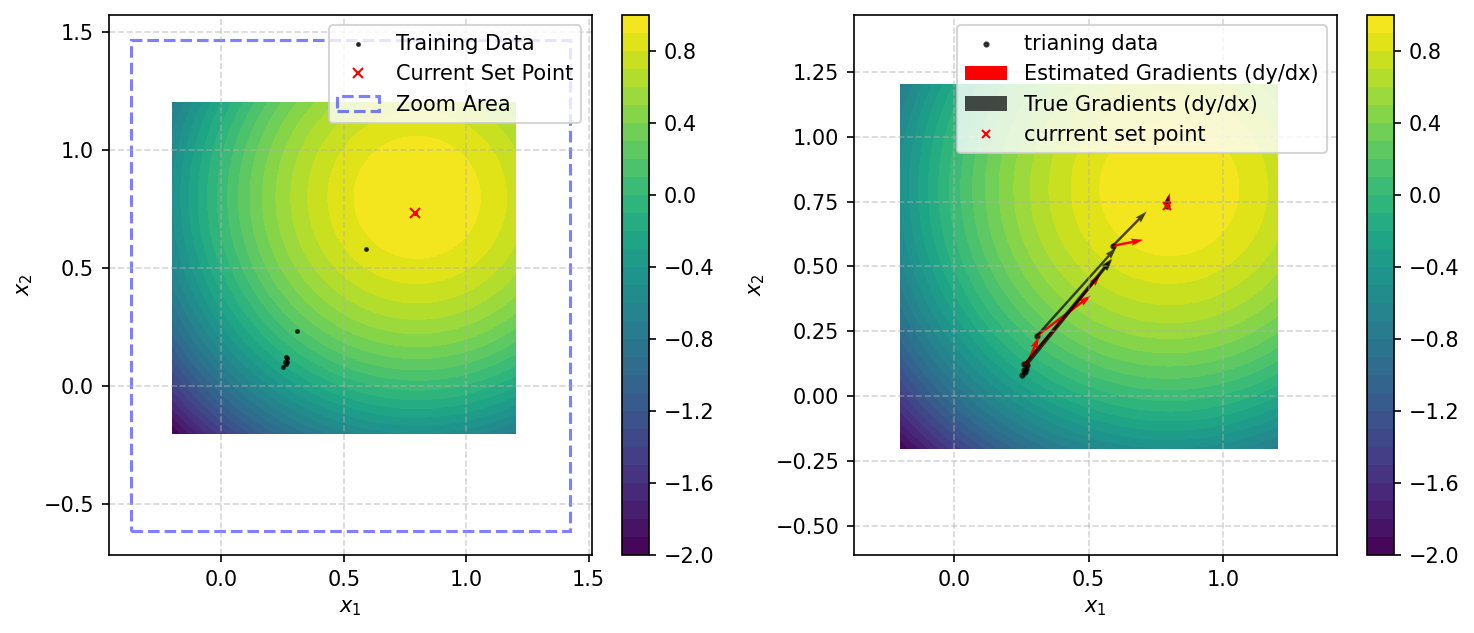

x.shape, dxdy.shape,dxdy_true.shape torch.Size([14, 2]) (10, 2) (10, 2)


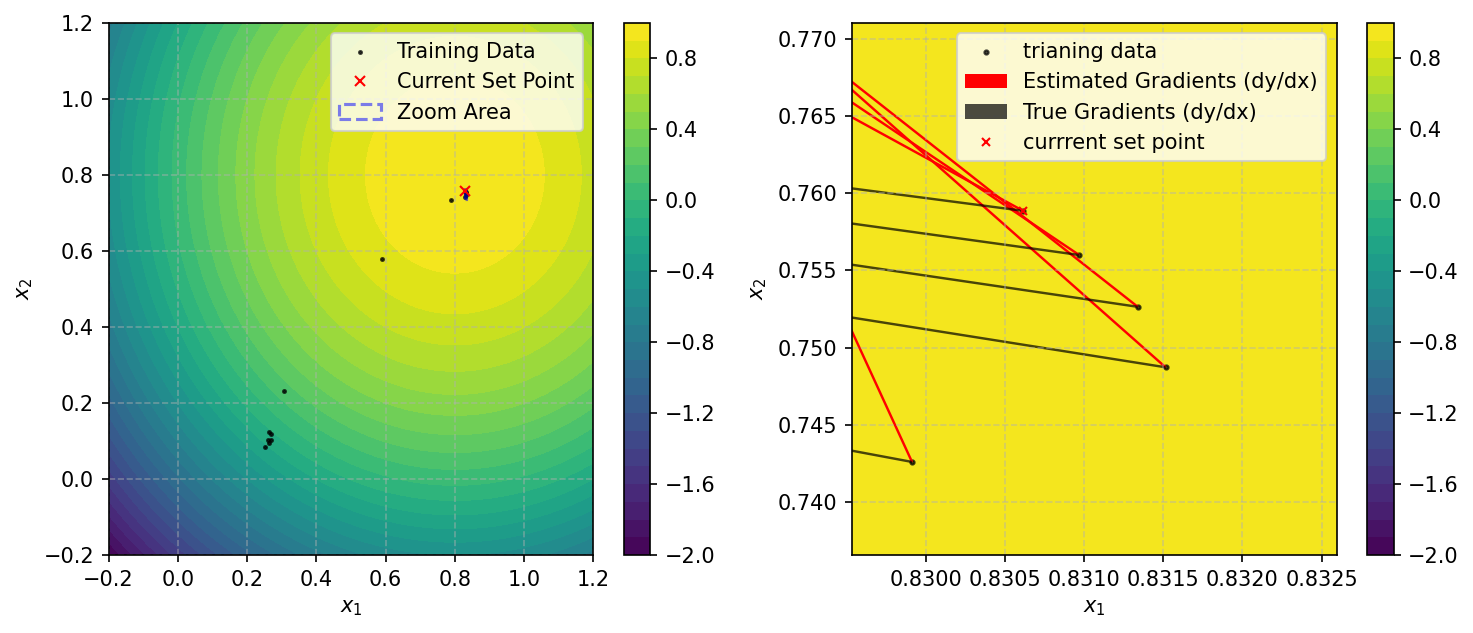

x.shape, dxdy.shape,dxdy_true.shape torch.Size([25, 2]) (21, 2) (21, 2)


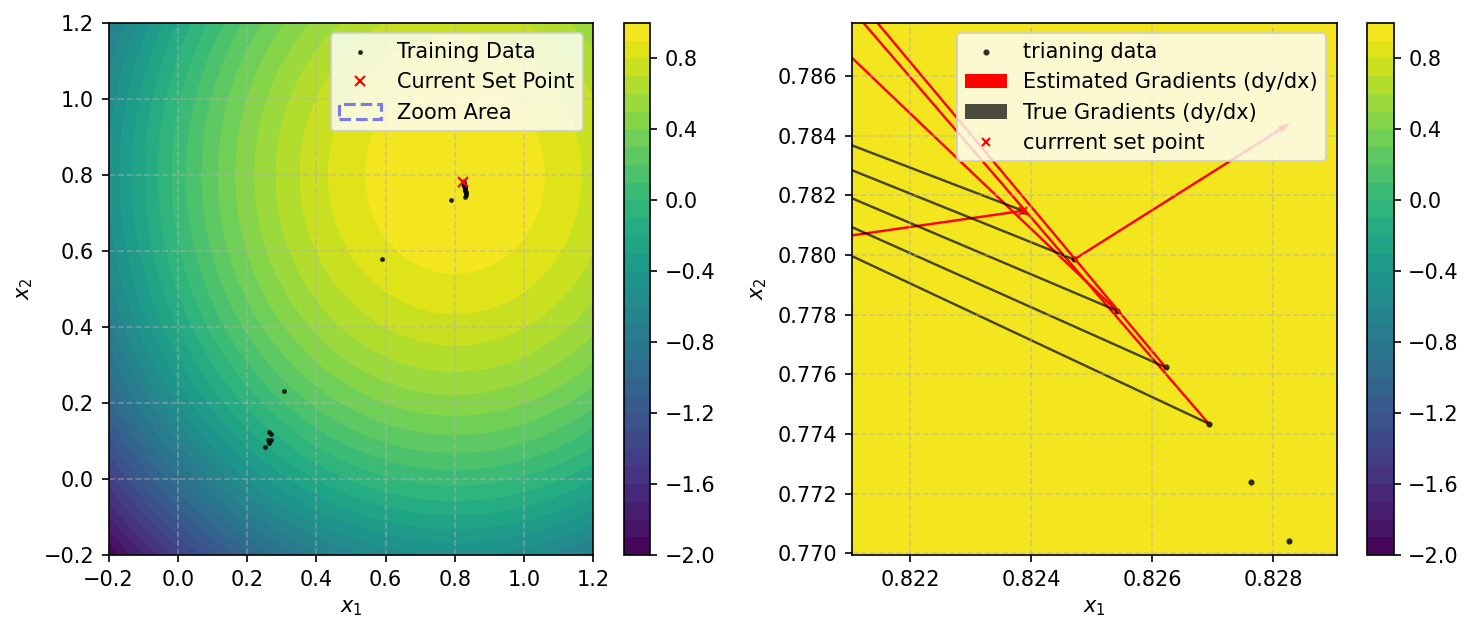

x.shape, dxdy.shape,dxdy_true.shape torch.Size([40, 2]) (36, 2) (36, 2)


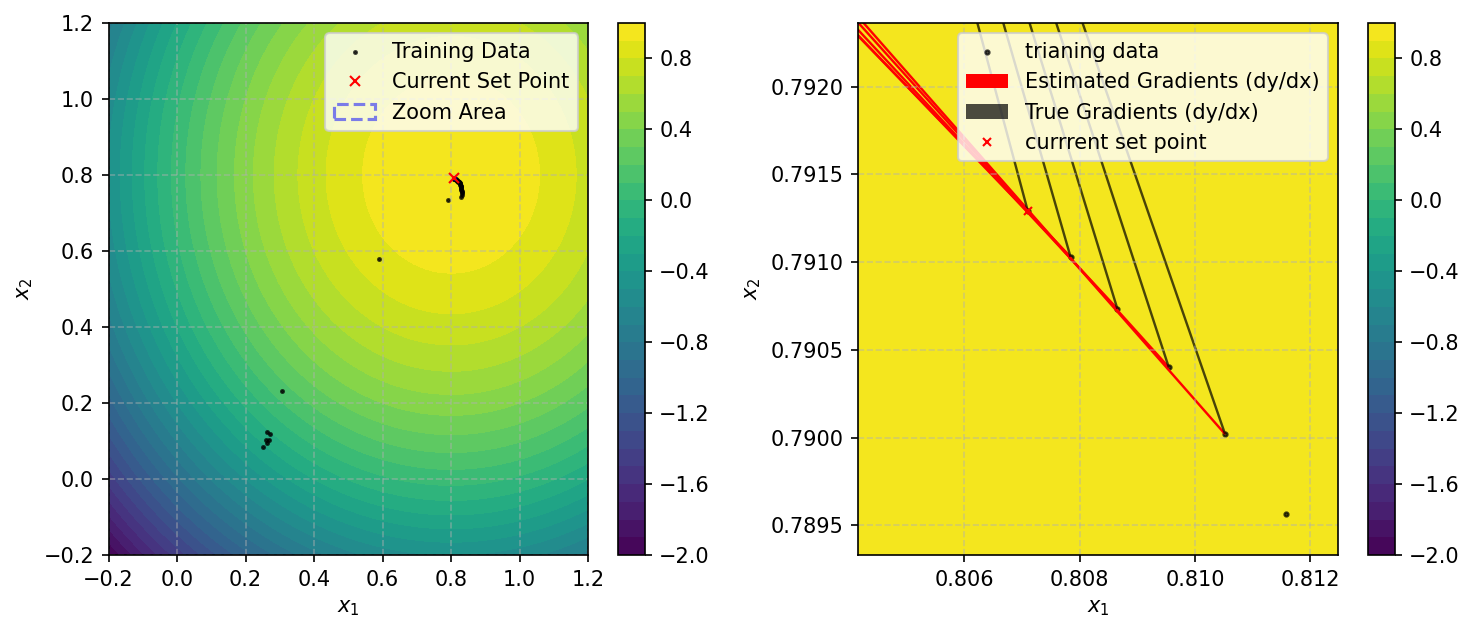

In [46]:
plot_grad(sv,epoch=ninit+5)
plot_grad(sv,epoch=int(0.3*(budget-ninit))+ninit)
plot_grad(sv,epoch=int(0.6*(budget-ninit))+ninit)
plot_grad(sv,epoch=budget)

# SG penalize_uncertain_gradient

In [47]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, lrES=lrES)
for i in range(ninit):
    sv.step(lr=0)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES_scaler=0,penalize_uncertain_gradient=True)

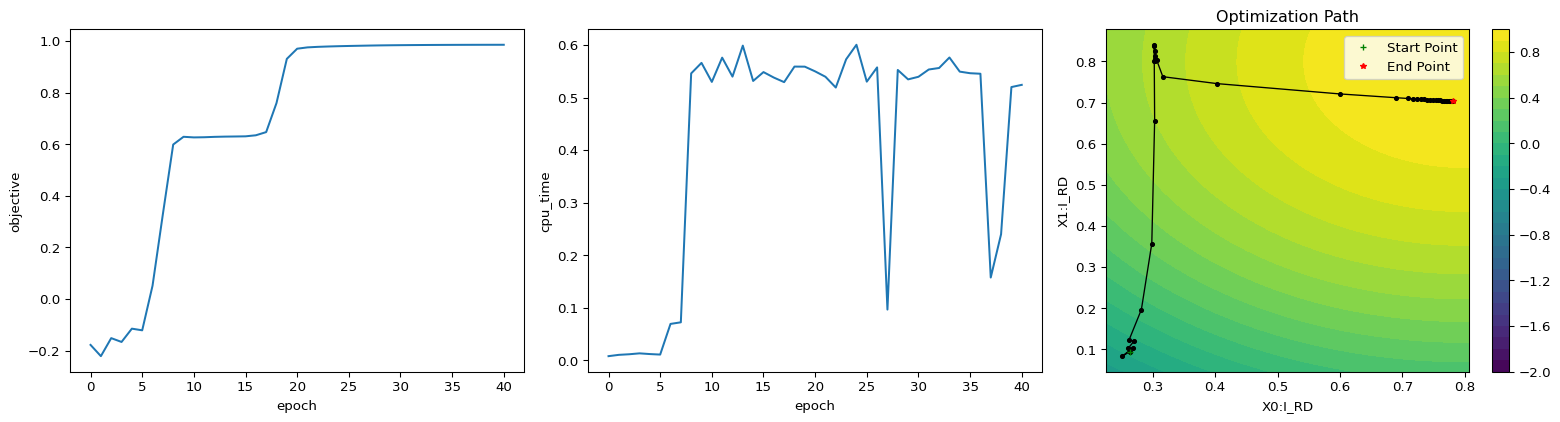

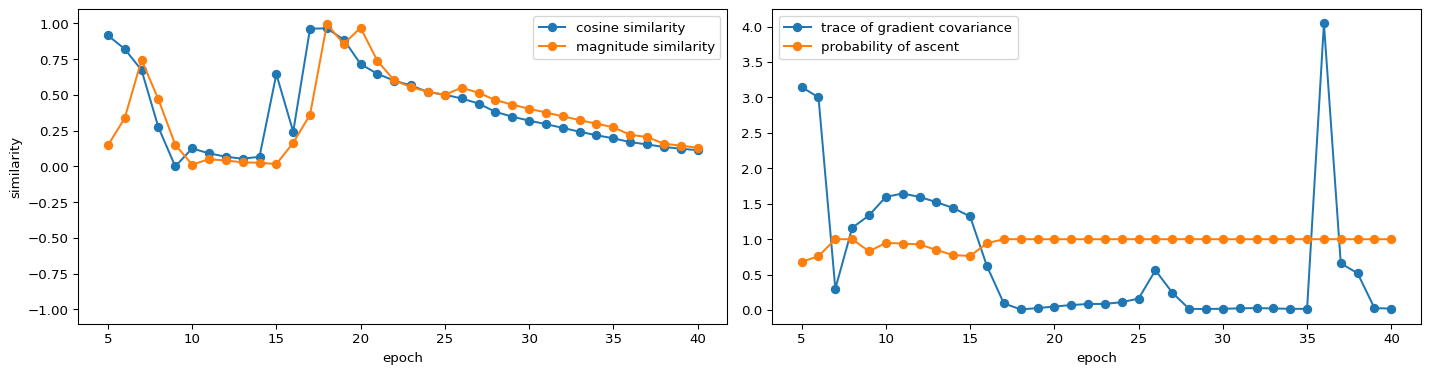

In [48]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

x.shape, dxdy.shape,dxdy_true.shape torch.Size([9, 2]) (5, 2) (5, 2)


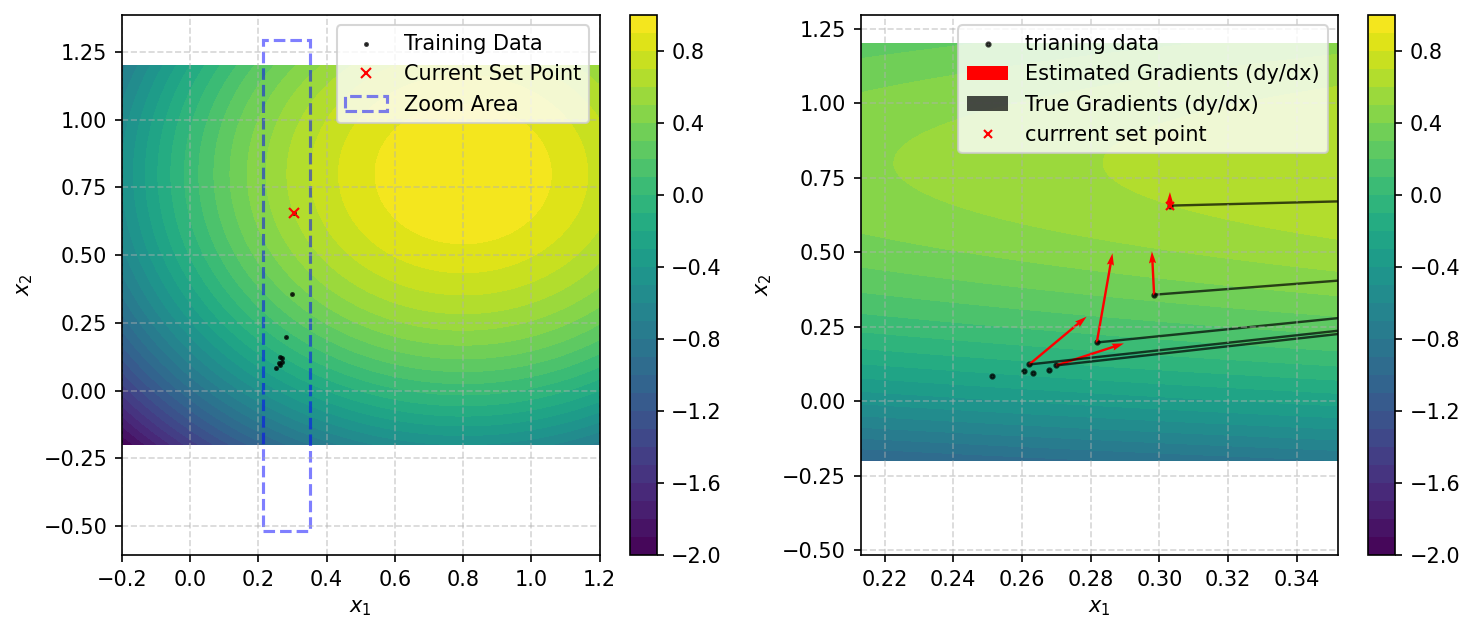

x.shape, dxdy.shape,dxdy_true.shape torch.Size([14, 2]) (10, 2) (10, 2)


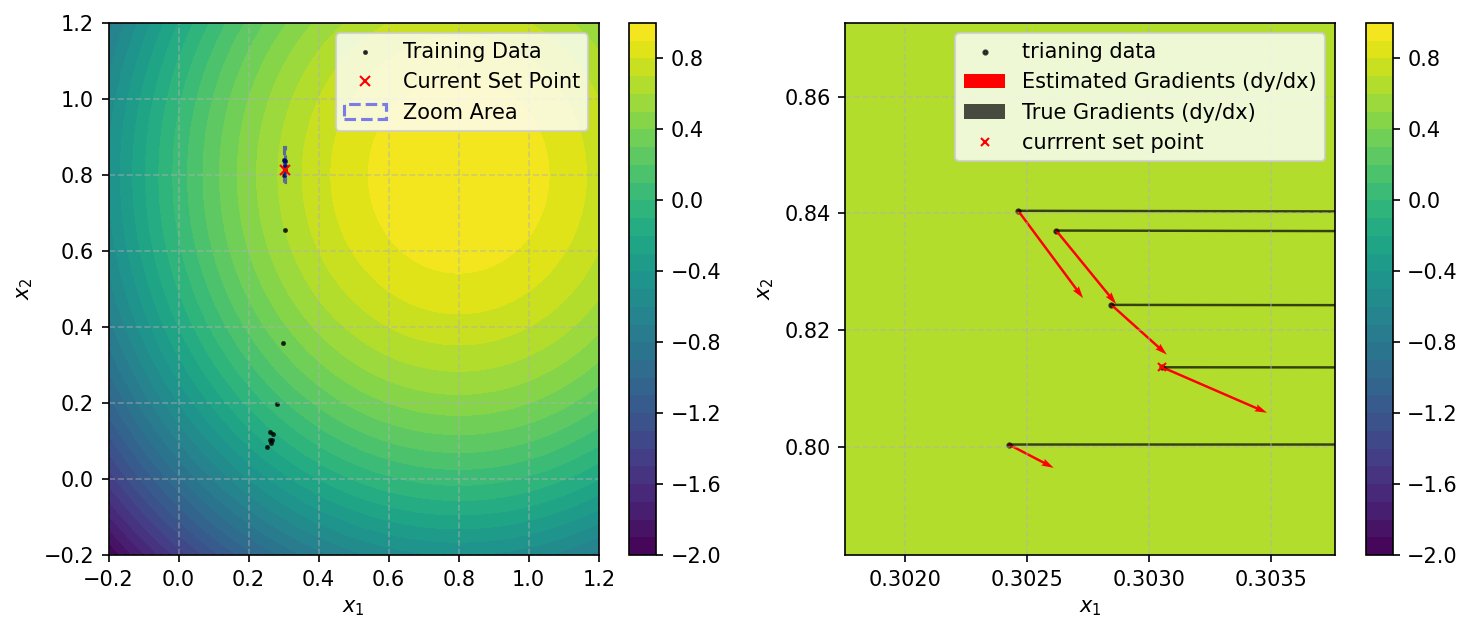

x.shape, dxdy.shape,dxdy_true.shape torch.Size([25, 2]) (21, 2) (21, 2)


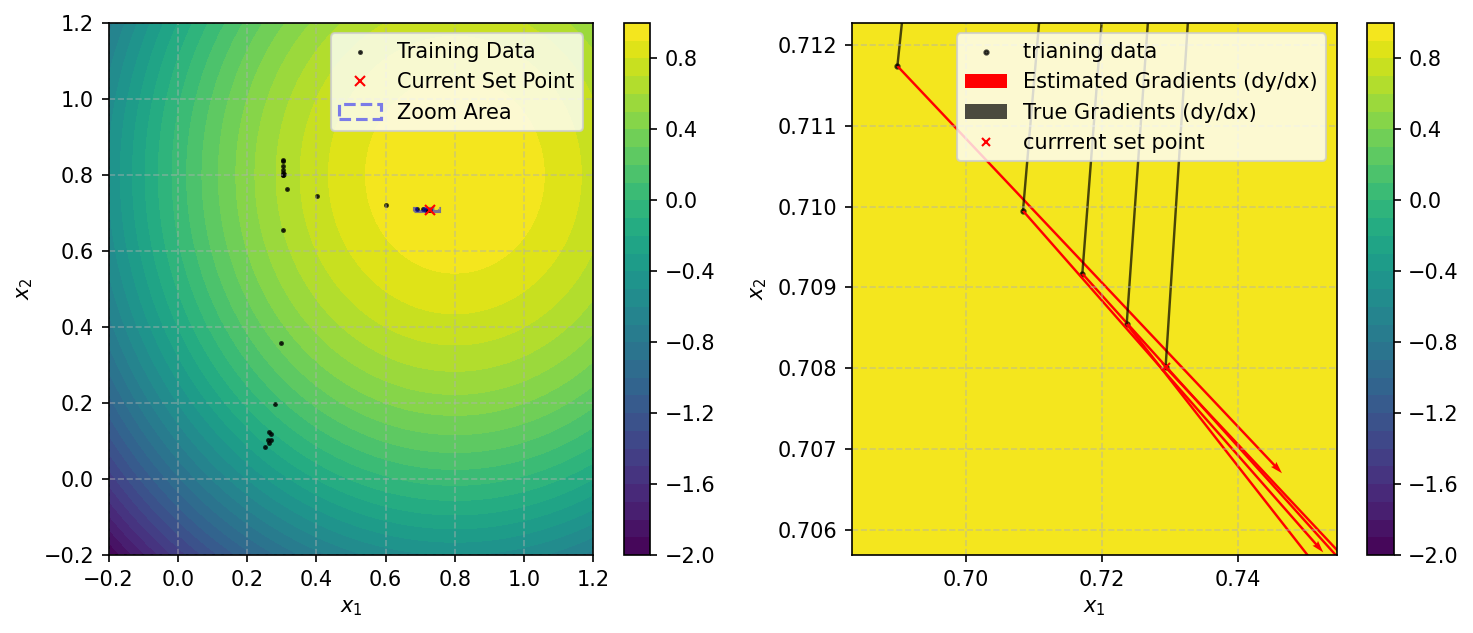

x.shape, dxdy.shape,dxdy_true.shape torch.Size([40, 2]) (36, 2) (36, 2)


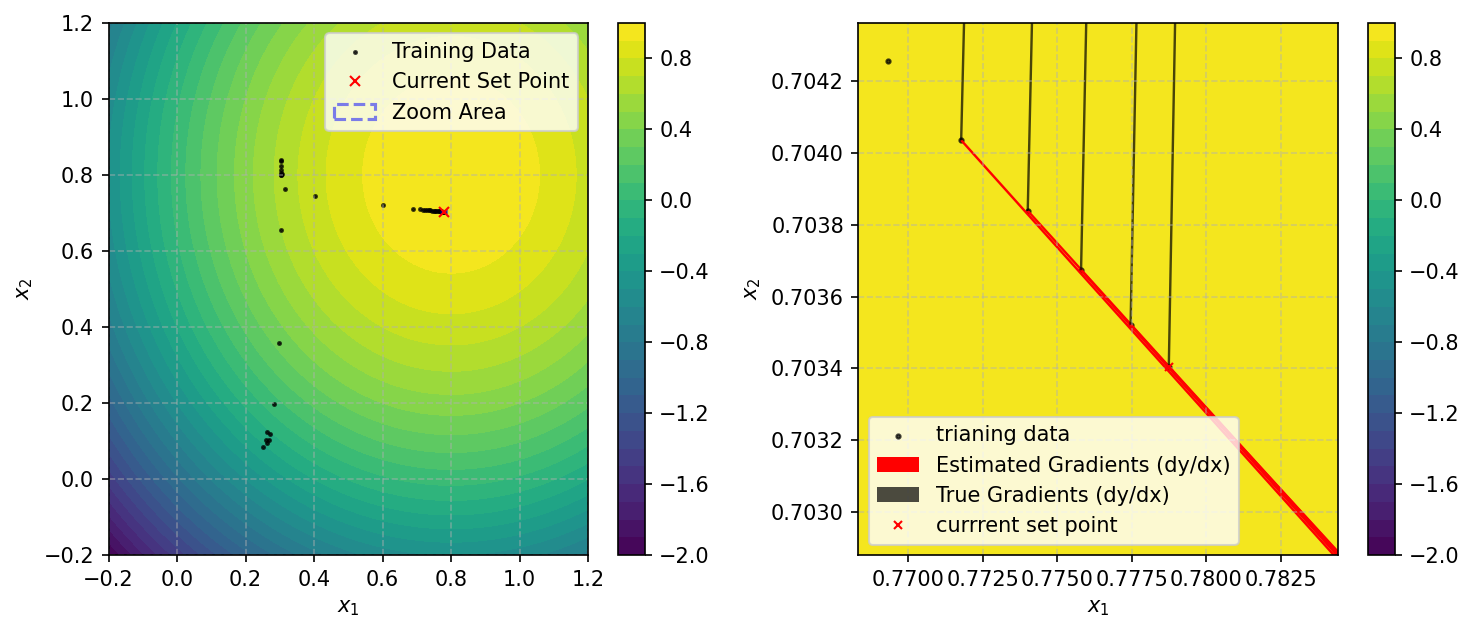

In [49]:
plot_grad(sv,epoch=ninit+5)
plot_grad(sv,epoch=int(0.3*(budget-ninit))+ninit)
plot_grad(sv,epoch=int(0.6*(budget-ninit))+ninit)
plot_grad(sv,epoch=budget)

In [50]:
svSGuncertain = copy(sv.history)
evSGuncertain = copy(sv.evaluator.get_history()['mean'])

# adamSG wo ES

In [51]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
optimizer = adam()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, optimizer=optimizer, lrES=lrES)
for i in range(ninit):
    sv.step(lr=0)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES_scaler=0)

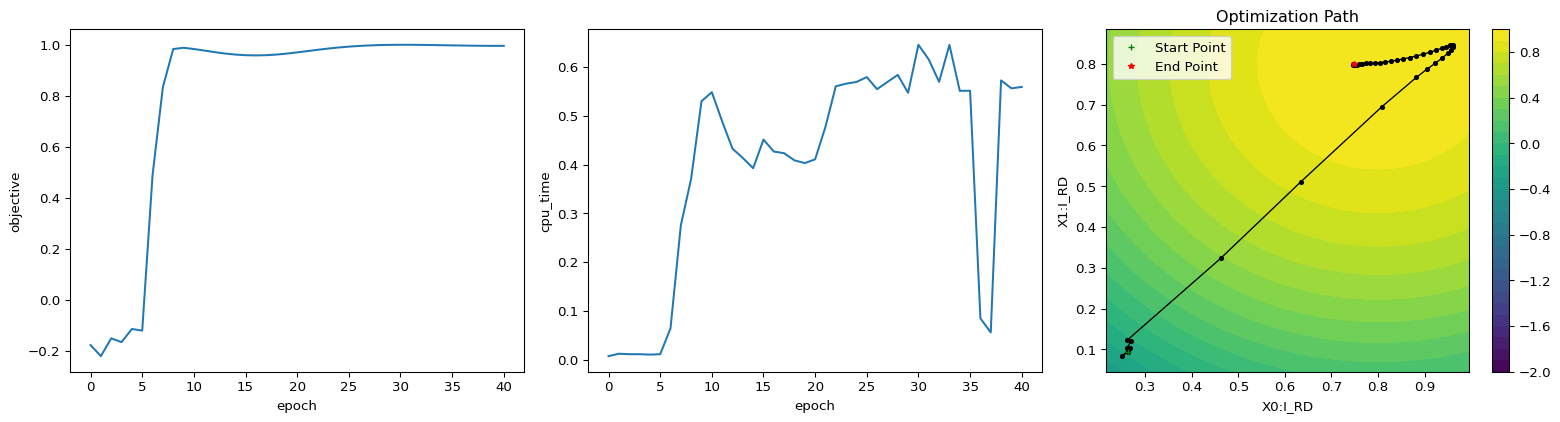

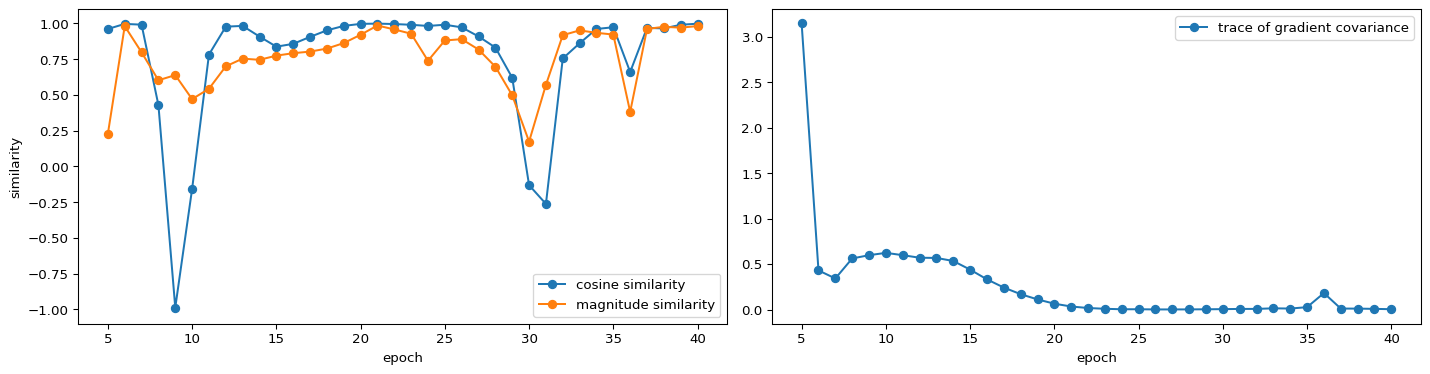

In [52]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

x.shape, dxdy.shape,dxdy_true.shape torch.Size([9, 2]) (5, 2) (5, 2)


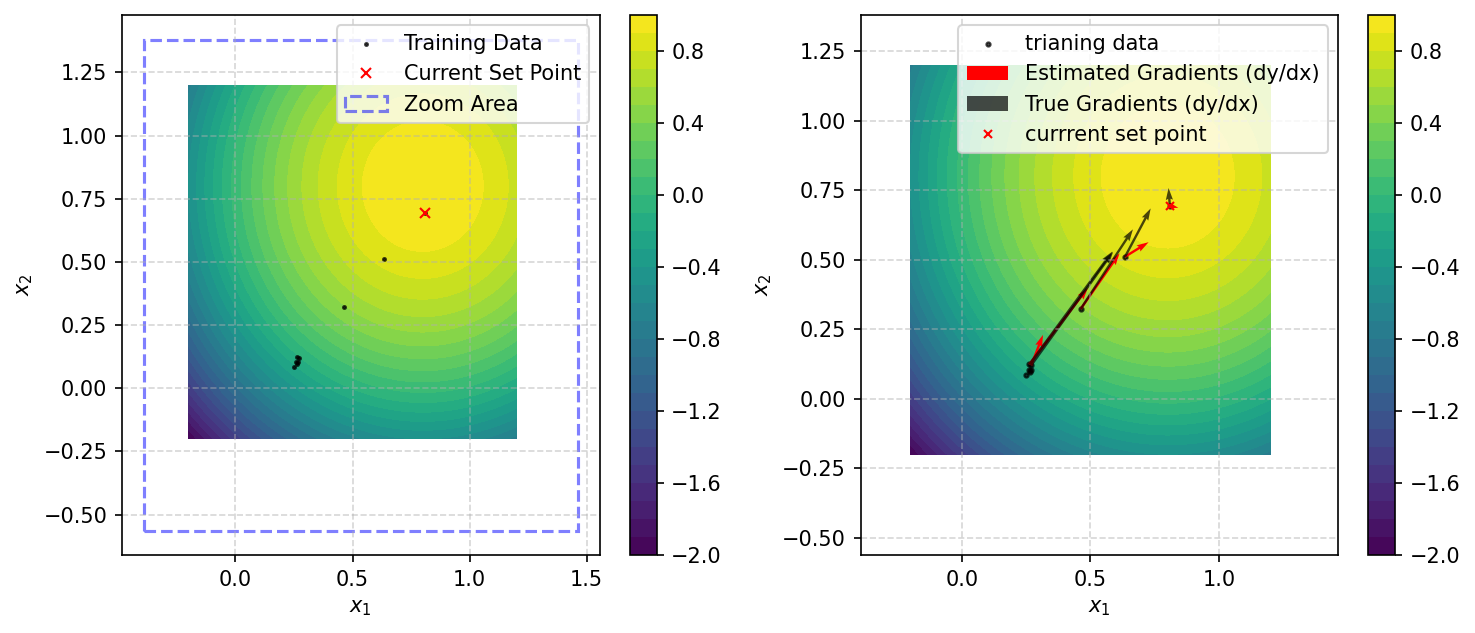

x.shape, dxdy.shape,dxdy_true.shape torch.Size([14, 2]) (10, 2) (10, 2)


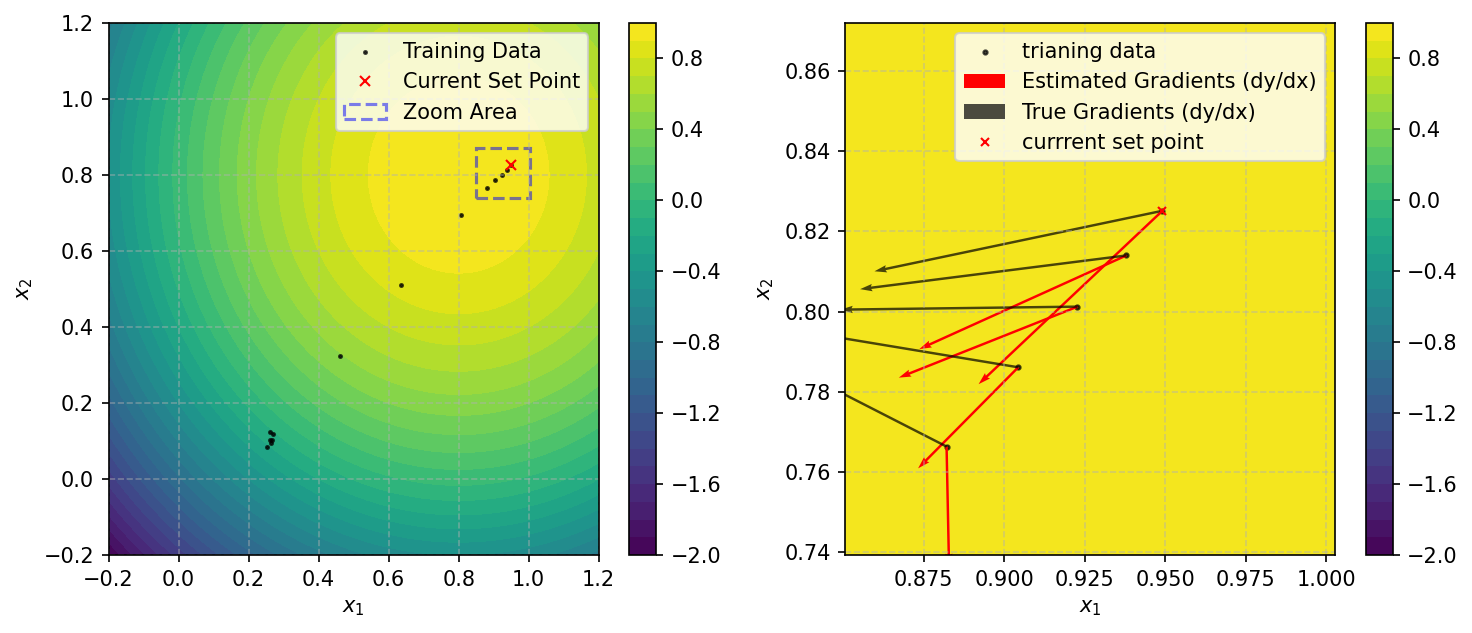

x.shape, dxdy.shape,dxdy_true.shape torch.Size([25, 2]) (21, 2) (21, 2)


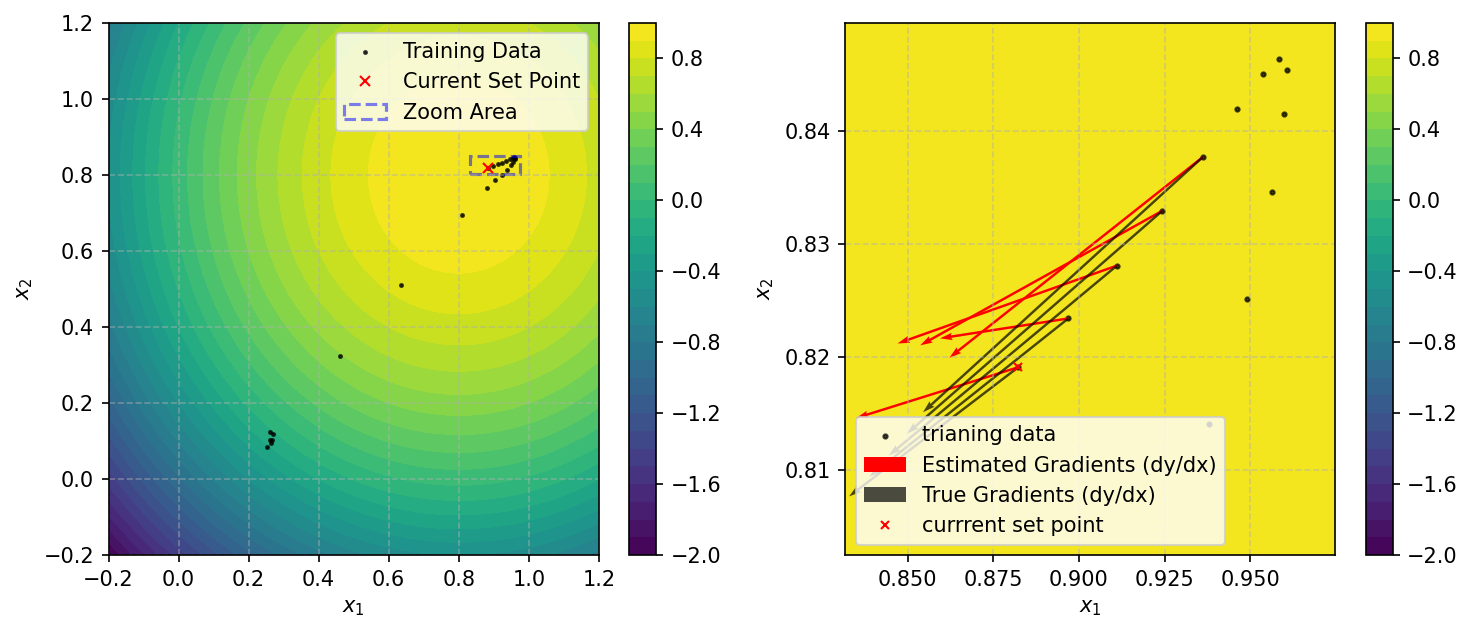

x.shape, dxdy.shape,dxdy_true.shape torch.Size([40, 2]) (36, 2) (36, 2)


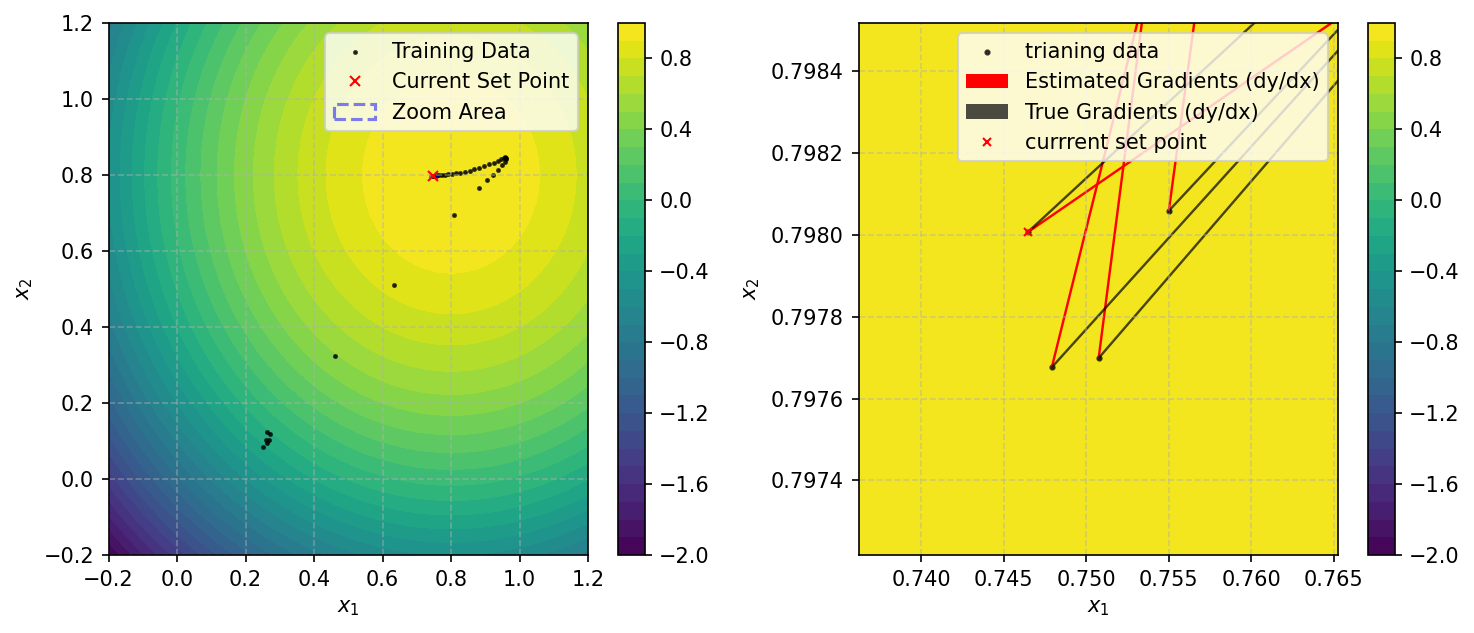

In [53]:
plot_grad(sv,epoch=ninit+5)
plot_grad(sv,epoch=int(0.3*(budget-ninit))+ninit)
plot_grad(sv,epoch=int(0.6*(budget-ninit))+ninit)
plot_grad(sv,epoch=budget)

In [54]:
svAdamSG = copy(sv.history)
evAdamSG = copy(sv.evaluator.get_history()['mean'])

# adamSG w ES penalize_uncertain_gradient

In [55]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
optimizer = adam()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, optimizer=optimizer, lrES=lrES)
for i in range(ninit):
    sv.step(lr=0)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES_scaler=0,penalize_uncertain_gradient=True)

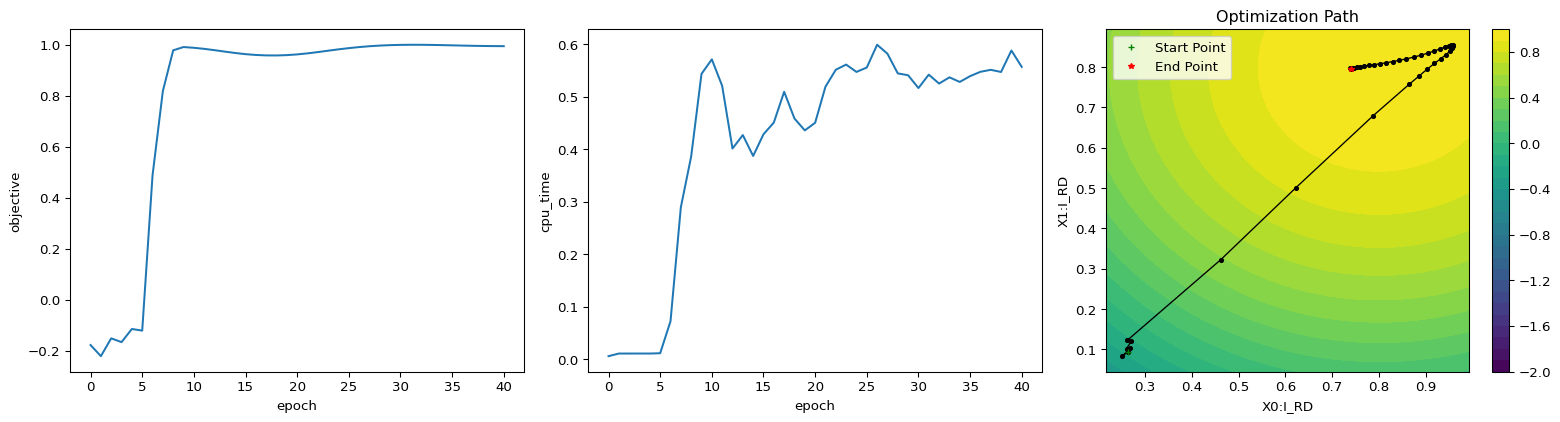

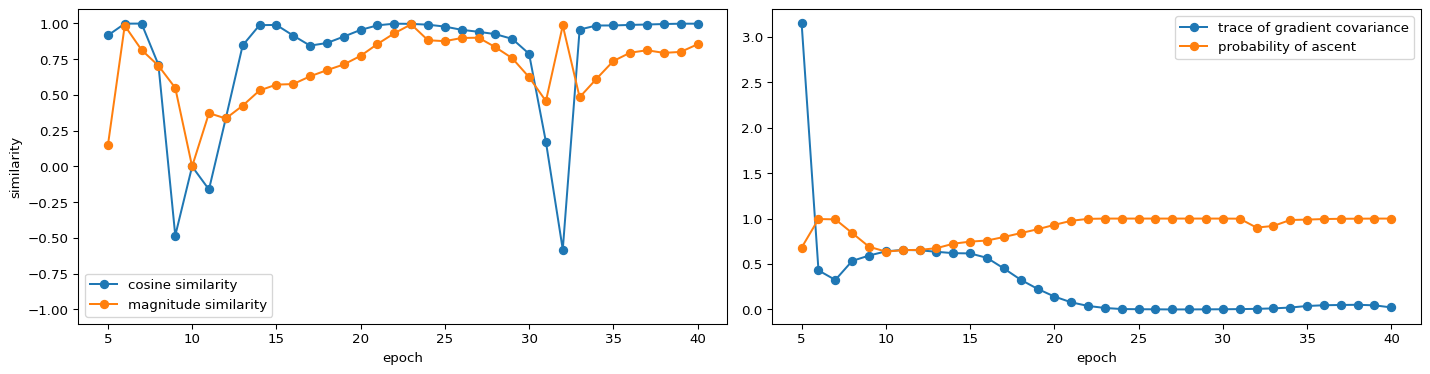

In [56]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

x.shape, dxdy.shape,dxdy_true.shape torch.Size([9, 2]) (5, 2) (5, 2)


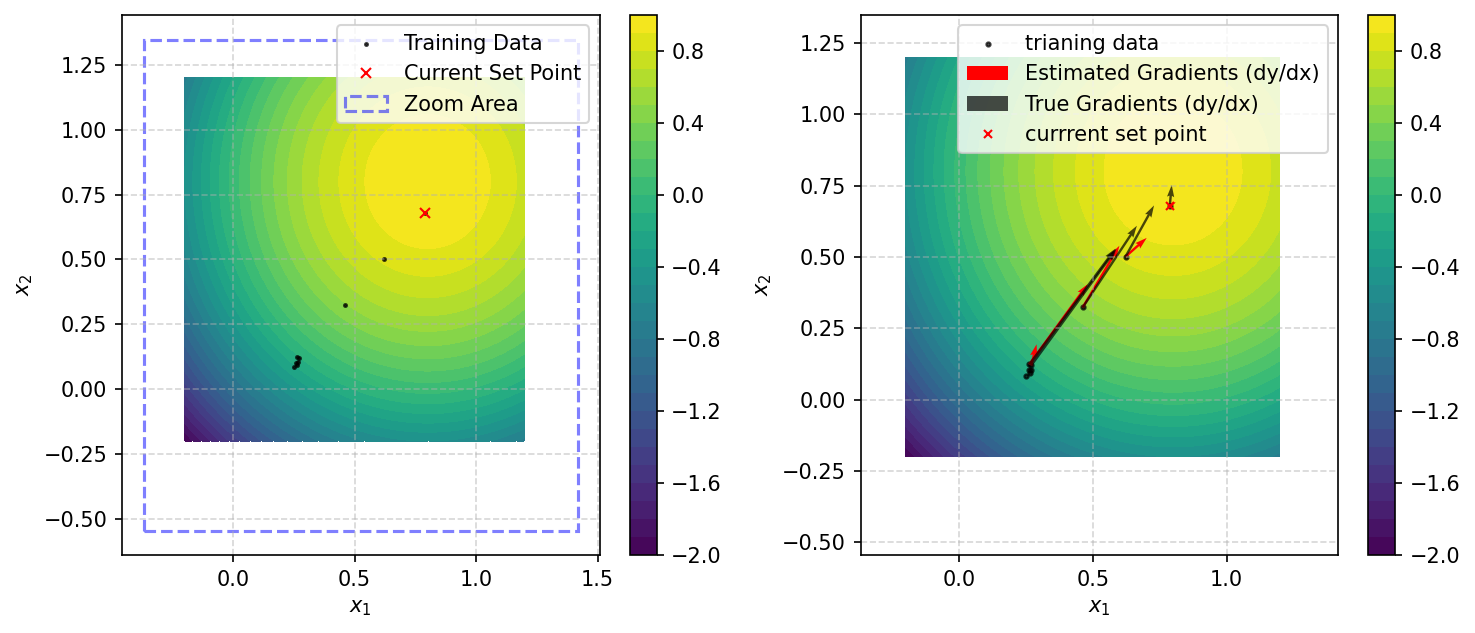

x.shape, dxdy.shape,dxdy_true.shape torch.Size([14, 2]) (10, 2) (10, 2)


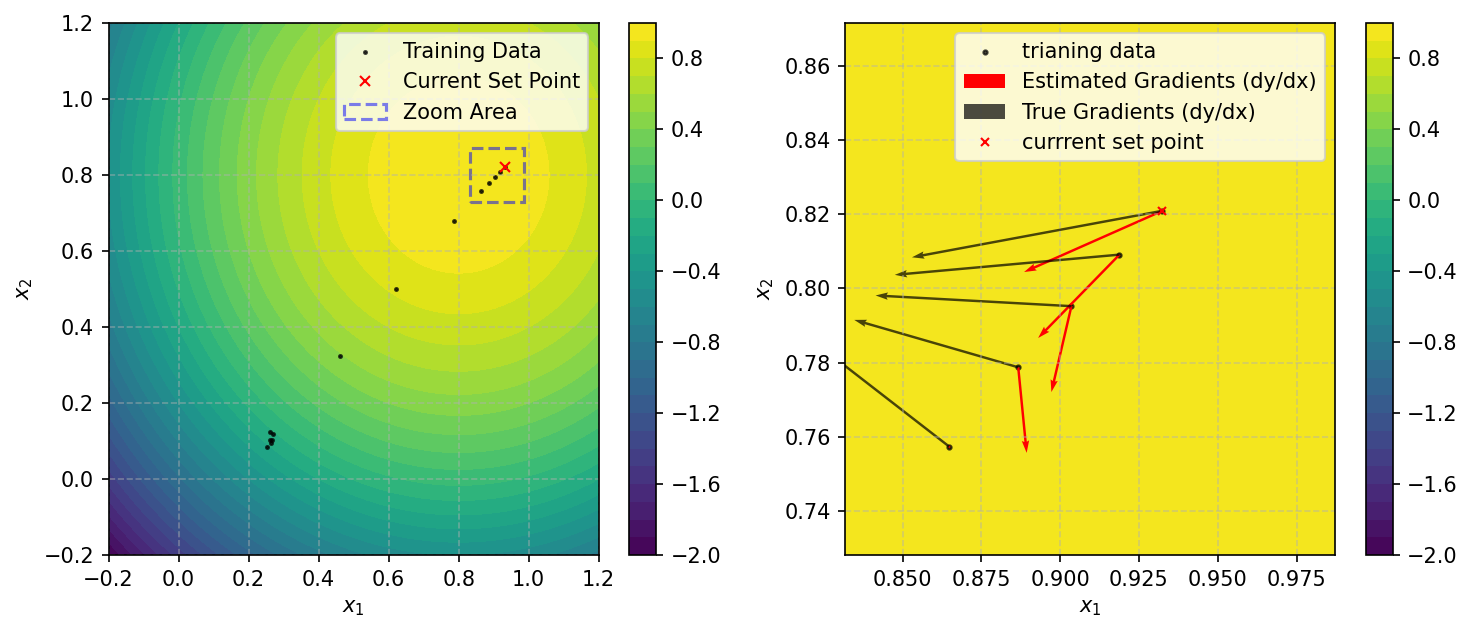

x.shape, dxdy.shape,dxdy_true.shape torch.Size([25, 2]) (21, 2) (21, 2)


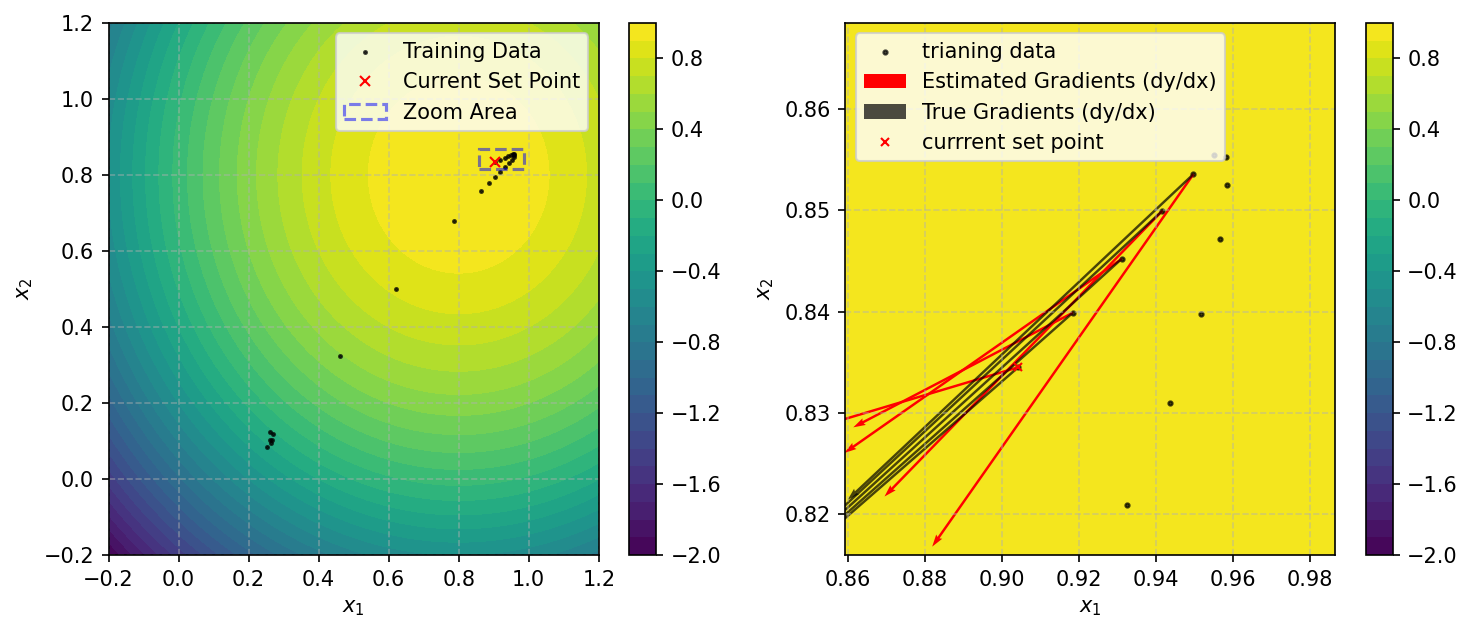

x.shape, dxdy.shape,dxdy_true.shape torch.Size([40, 2]) (36, 2) (36, 2)


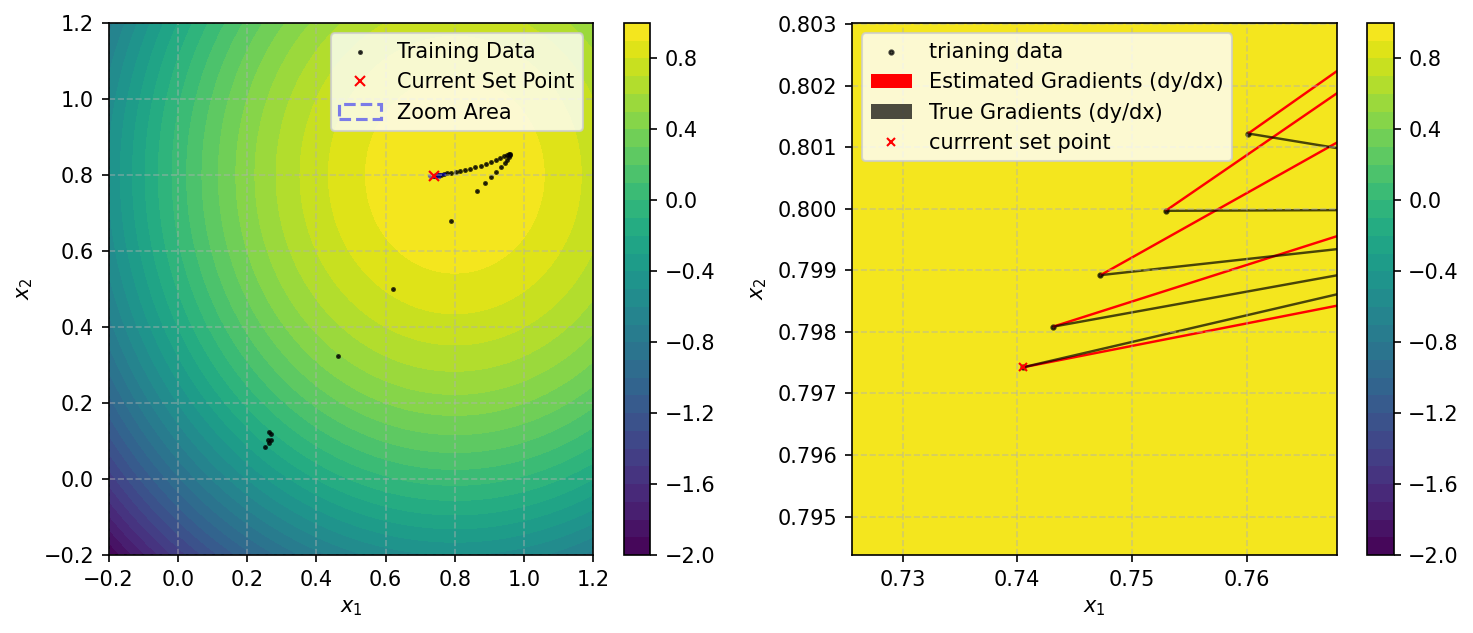

In [57]:
plot_grad(sv,epoch=ninit+5)
plot_grad(sv,epoch=int(0.3*(budget-ninit))+ninit)
plot_grad(sv,epoch=int(0.6*(budget-ninit))+ninit)
plot_grad(sv,epoch=budget)

In [58]:
svAdamSGuncertain = copy(sv.history)
evAdamSGuncertain = copy(sv.evaluator.get_history()['mean'])

# TurBO

In [59]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
optimizer = adam()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, optimizer=optimizer, lrES=lrES)
for i in range(ninit):
    sv.step(lr=0)
for i in range(budget-ninit):
    sv.step(TurBO=True)

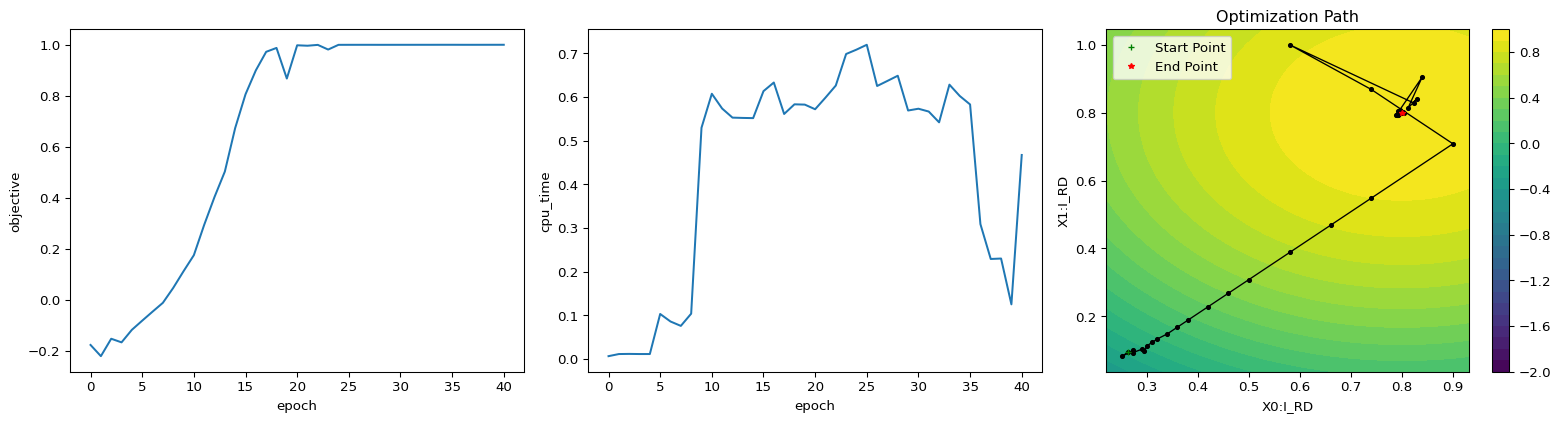

In [60]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [61]:
svTurBO = copy(sv.history)
evTurBO = copy(sv.evaluator.get_history()['mean'])

# aggregate

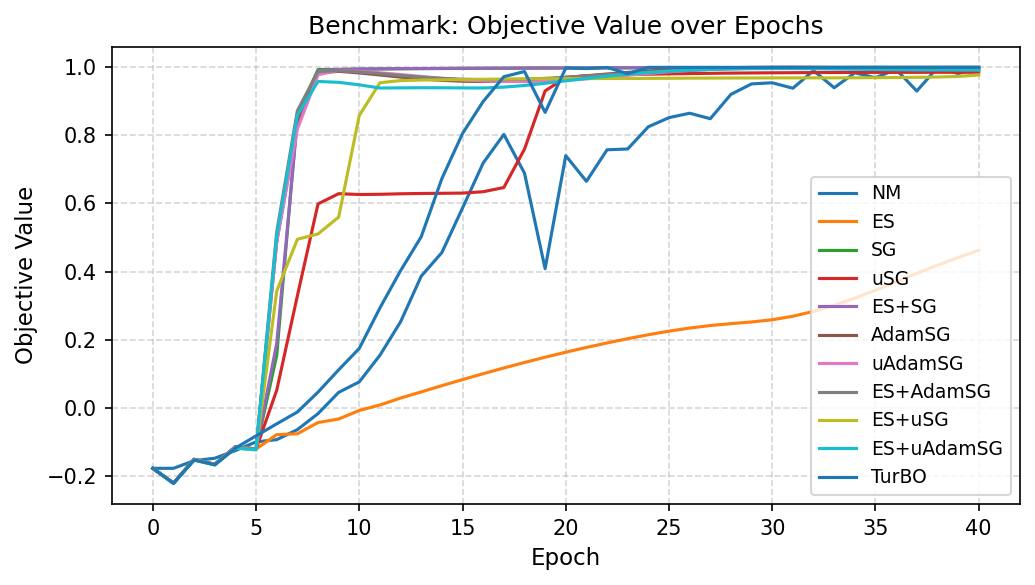

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'NM': svNM,
    'ES': svES,
    'SG': svSG,
    'uSG': svSGuncertain,
    'ES+SG': svSGES,
    'AdamSG': svAdamSG,
    'uAdamSG': svAdamSGuncertain,
    'ES+AdamSG': svAdamSGES,
    'ES+uSG': svSGESuncertain,
    'ES+uAdamSG': svAdamSGESuncertain,
    'TurBO': svTurBO,
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
# plt.savefig(f'{fname}_full.png',dpi=150)

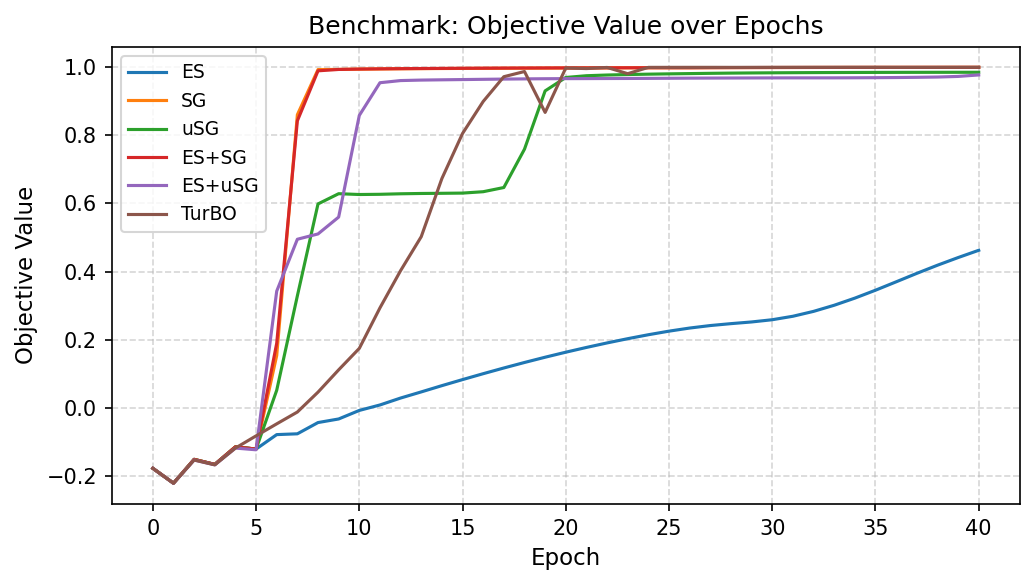

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'ES': svES,
    'SG': svSG,
    'uSG': svSGuncertain,
    'ES+SG': svSGES,
    'ES+uSG': svSGESuncertain,
    # 'AdamSG': svAdamSG,
    # 'uAdamSG': svAdamSGuncertain,
    # 'ES+AdamSG': svAdamSGES,
    # 'ES+uAdamSG': svAdamSGESuncertain,
    'TurBO': svTurBO,
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
# plt.savefig(f'{fname}_SG.png',dpi=150)

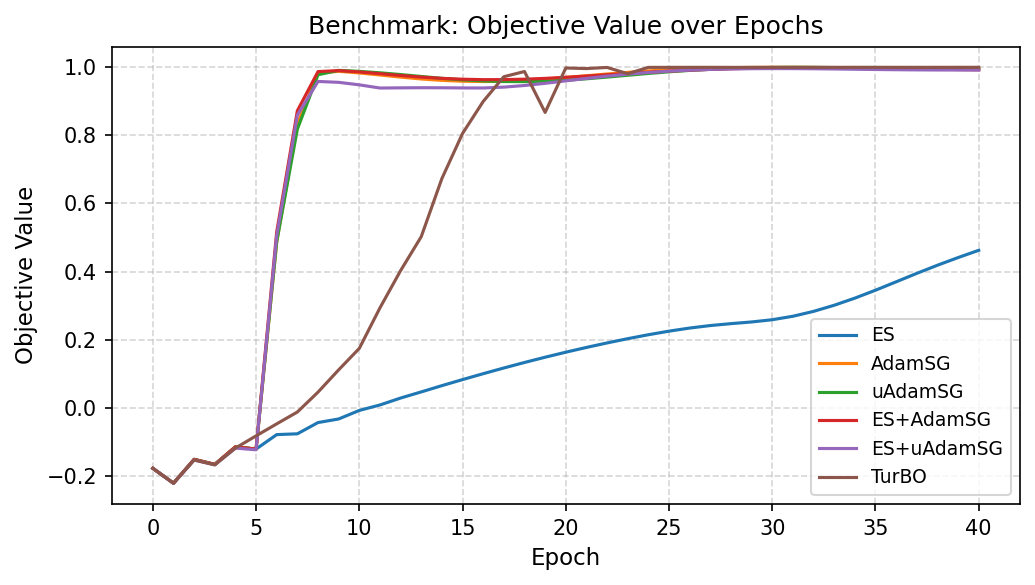

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'ES': svES,
    # 'SG': svSG,
    # 'uSG': svSGuncertain,
    # 'ES+SG': svSGES,
    # 'ES+uSG': svSGESuncertain,
    'AdamSG': svAdamSG,
    'uAdamSG': svAdamSGuncertain,
    'ES+AdamSG': svAdamSGES,
    'ES+uAdamSG': svAdamSGESuncertain,
    'TurBO': svTurBO,
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
# plt.savefig(f'{fname}_adamSG.png',dpi=150)

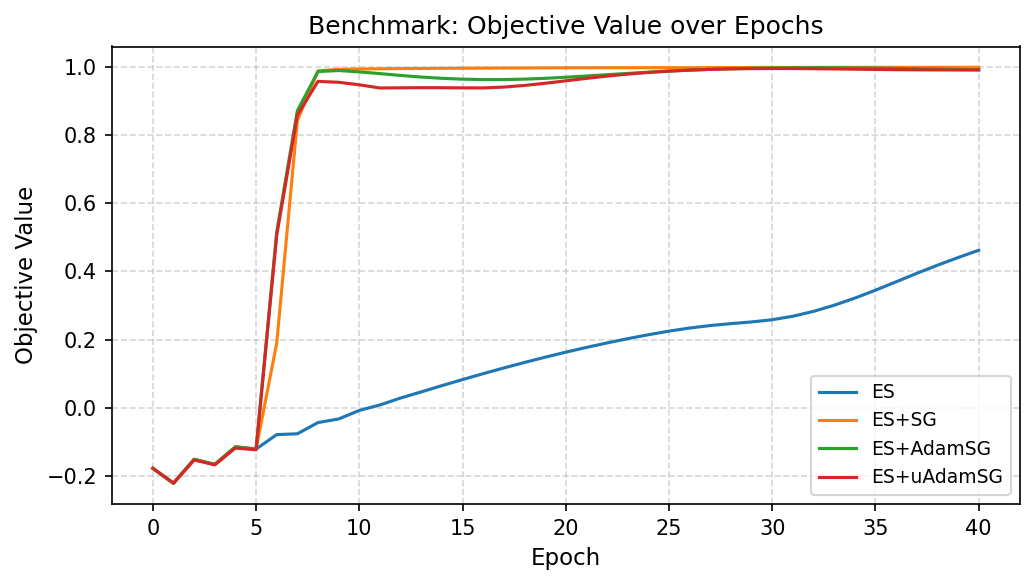

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'ES': svES,
    # 'SG': svSG,
    # 'uSG': svSGuncertain,
    'ES+SG': svSGES,
    # 'ES+uSG': svSGESuncertain,
    # 'AdamSG': svAdamSG,
    # 'uAdamSG': svAdamSGuncertain,
    'ES+AdamSG': svAdamSGES,
    'ES+uAdamSG': svAdamSGESuncertain
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
# plt.savefig(f'{fname}__brief.png',dpi=150)

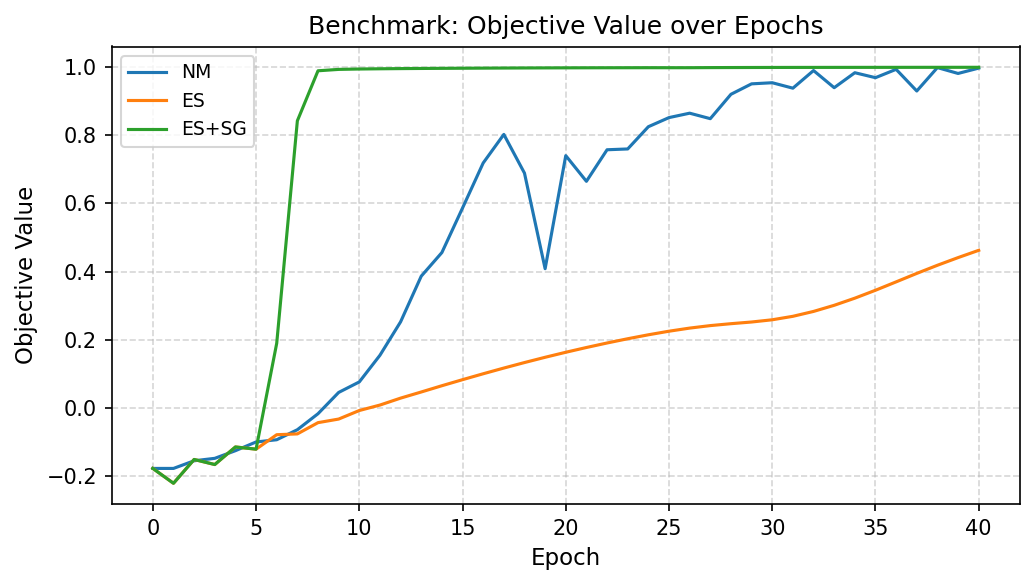

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'NM': svNM,
    'ES': svES,
    # 'SG': svSG,
    # 'uSG': svSGuncertain,
    'ES+SG': svSGES,
    # 'ES+uSG': svSGESuncertain,
    # 'AdamSG': svAdamSG,
    # 'uAdamSG': svAdamSGuncertain,
    # 'ES+AdamSG': svAdamSGES,
    # 'ES+uAdamSG': svAdamSGESuncertain
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
# plt.savefig(f'{fname}_ESvsESSG.png',dpi=150)